In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Chemin vers le dataset
data_path = Path("PlantVillage")

# Lister toutes les classes
classes = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
print(f"Nombre de classes : {len(classes)}")
print("\nListe des classes :")
for c in classes:
    print(f"  - {c}")

Nombre de classes : 16

Liste des classes :
  - Pepper__bell___Bacterial_spot
  - Pepper__bell___healthy
  - PlantVillage
  - Potato___Early_blight
  - Potato___Late_blight
  - Potato___healthy
  - Tomato_Bacterial_spot
  - Tomato_Early_blight
  - Tomato_Late_blight
  - Tomato_Leaf_Mold
  - Tomato_Septoria_leaf_spot
  - Tomato_Spider_mites_Two_spotted_spider_mite
  - Tomato__Target_Spot
  - Tomato__Tomato_YellowLeaf__Curl_Virus
  - Tomato__Tomato_mosaic_virus
  - Tomato_healthy


In [2]:
# On filtre le sous-dossier "PlantVillage" parasite
classes = sorted([
    d.name for d in data_path.iterdir() 
    if d.is_dir() and d.name != "PlantVillage"
])

# Compter les images par classe
counts = {}
for cls in classes:
    images = list((data_path / cls).glob("*.jpg"))
    counts[cls] = len(images)

# Afficher le total
total = sum(counts.values())
print(f"Nombre de classes valides : {len(classes)}")
print(f"Nombre total d'images     : {total}")
print()
for cls, n in counts.items():
    print(f"  {n:>5} images  →  {cls}")

Nombre de classes valides : 15
Nombre total d'images     : 20636

    997 images  →  Pepper__bell___Bacterial_spot
   1477 images  →  Pepper__bell___healthy
   1000 images  →  Potato___Early_blight
   1000 images  →  Potato___Late_blight
    152 images  →  Potato___healthy
   2127 images  →  Tomato_Bacterial_spot
   1000 images  →  Tomato_Early_blight
   1908 images  →  Tomato_Late_blight
    952 images  →  Tomato_Leaf_Mold
   1771 images  →  Tomato_Septoria_leaf_spot
   1676 images  →  Tomato_Spider_mites_Two_spotted_spider_mite
   1404 images  →  Tomato__Target_Spot
   3208 images  →  Tomato__Tomato_YellowLeaf__Curl_Virus
    373 images  →  Tomato__Tomato_mosaic_virus
   1591 images  →  Tomato_healthy


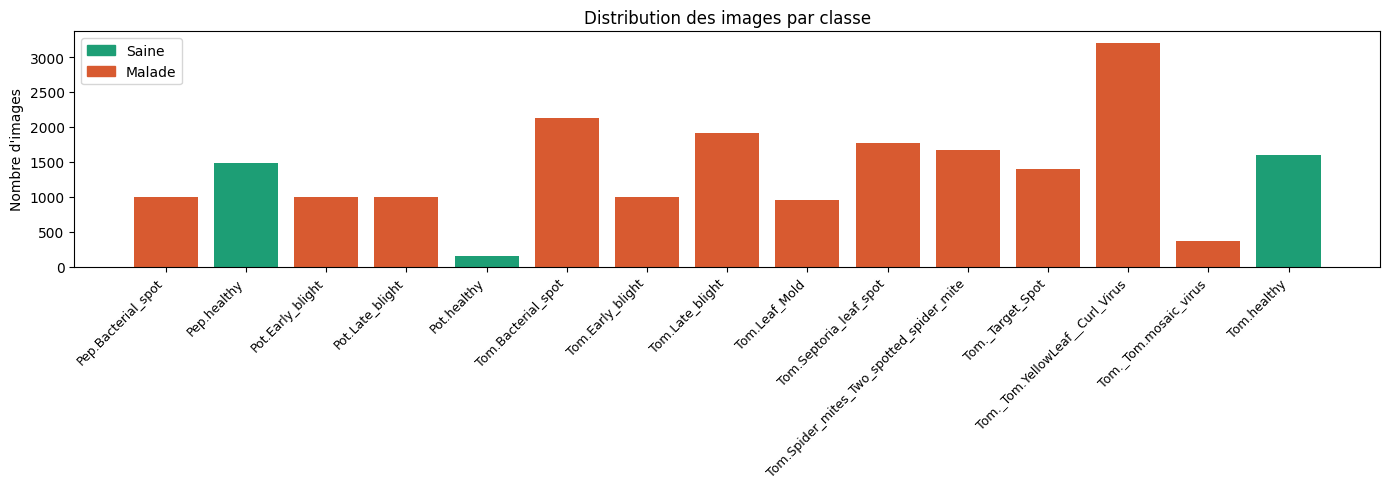

Graphique sauvegardé !


In [3]:
import matplotlib.pyplot as plt

# Noms courts pour l'affichage
short_names = [c.replace("Tomato_", "Tom.").replace("Potato___", "Pot.").replace("Pepper__bell___", "Pep.") for c in counts.keys()]

plt.figure(figsize=(14, 5))
bars = plt.bar(short_names, counts.values(), color=[
    "#1D9E75" if "healthy" in c else "#D85A30" for c in counts.keys()
])
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Distribution des images par classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()

# Légende
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="#1D9E75", label="Saine"),
    Patch(color="#D85A30", label="Malade")
], loc="upper left")

plt.savefig("distribution.png", dpi=150)
plt.show()
print("Graphique sauvegardé !")

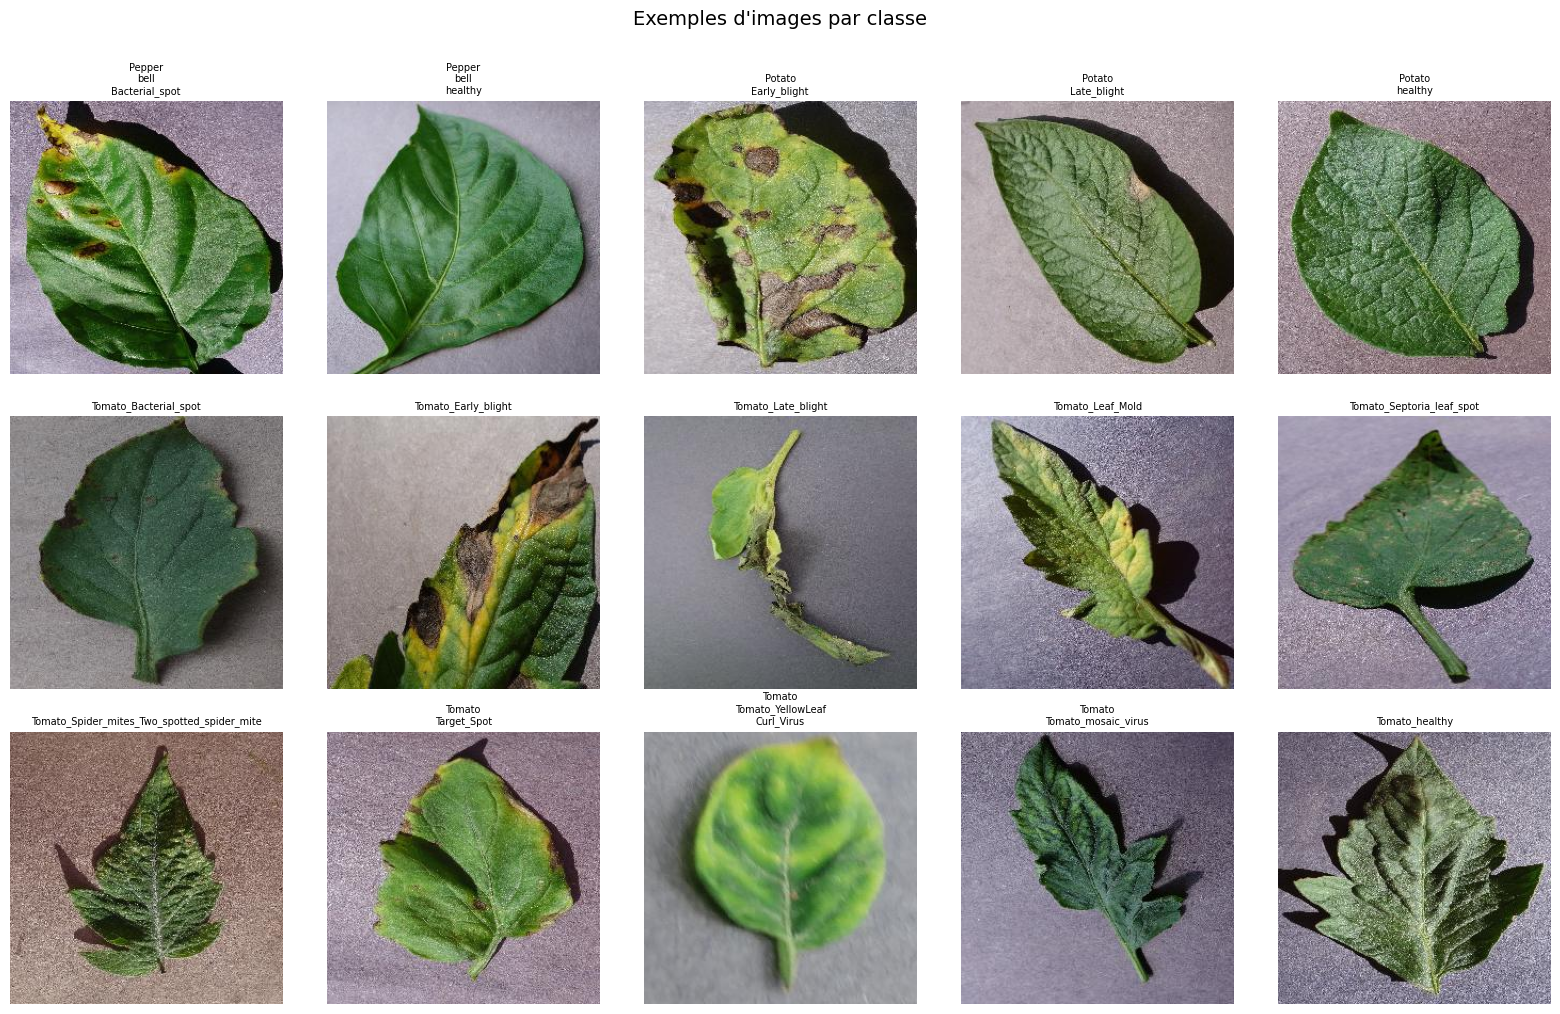

Exemples sauvegardés !


In [4]:
from PIL import Image
import random

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = data_path / cls
    images = list(cls_path.glob("*.jpg"))
    img_path = random.choice(images)
    img = Image.open(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(cls.replace("___", "\n").replace("__", "\n"), fontsize=7)
    axes[i].axis("off")

plt.suptitle("Exemples d'images par classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("exemples_classes.png", dpi=150)
plt.show()
print("Exemples sauvegardés !")

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Transformations des images
transform = transforms.Compose([
    transforms.Resize((224, 224)),        # Redimensionner toutes les images
    transforms.RandomHorizontalFlip(),    # Augmentation : miroir horizontal
    transforms.RandomRotation(10),        # Augmentation : légère rotation
    transforms.ToTensor(),                # Convertir en tenseur PyTorch
    transforms.Normalize(                 # Normalisation standard ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 2. Charger le dataset complet
dataset = datasets.ImageFolder(root="PlantVillage", transform=transform)

print(f"Classes détectées : {len(dataset.classes)}")
print(f"Total images      : {len(dataset)}")

Classes détectées : 16
Total images      : 24120


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Charger en excluant le sous-dossier "PlantVillage"
dataset = datasets.ImageFolder(
    root="PlantVillage",
    transform=transform,
    is_valid_file=lambda path: "PlantVillage\\PlantVillage" not in path
)

print(f"Classes détectées : {len(dataset.classes)}")
print(f"Total images      : {len(dataset)}")
print()
print("Classes :")
for c in dataset.classes:
    print(f"  - {c}")

FileNotFoundError: Found no valid file for the classes PlantVillage. 

In [7]:
import os

# Vérifier la structure exacte du dossier
for item in os.listdir("PlantVillage"):
    print(item)
    

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Pointer directement vers le bon sous-dossier
dataset = datasets.ImageFolder(
    root="PlantVillage/PlantVillage",
    transform=transform
)

print(f"Classes détectées : {len(dataset.classes)}")
print(f"Total images      : {len(dataset)}")

Classes détectées : 4
Total images      : 3482


In [9]:
import os

# Explorer jusqu'à 3 niveaux de profondeur
for level1 in os.listdir("PlantVillage"):
    path1 = os.path.join("PlantVillage", level1)
    if os.path.isdir(path1):
        items = os.listdir(path1)
        print(f"PlantVillage/{level1}/ → {len(items)} éléments")
        for item in items[:3]:  # Afficher les 3 premiers
            path2 = os.path.join(path1, item)
            if os.path.isdir(path2):
                n = len(os.listdir(path2))
                print(f"    └── {item}/ → {n} fichiers")

PlantVillage/Pepper__bell___Bacterial_spot/ → 997 éléments
PlantVillage/Pepper__bell___healthy/ → 1478 éléments
PlantVillage/PlantVillage/ → 4 éléments
    └── Pepper__bell___Bacterial_spot/ → 997 fichiers
    └── Pepper__bell___healthy/ → 1478 fichiers
    └── Potato___Early_blight/ → 1000 fichiers
PlantVillage/Potato___Early_blight/ → 1000 éléments
PlantVillage/Potato___healthy/ → 152 éléments
PlantVillage/Potato___Late_blight/ → 1000 éléments
PlantVillage/Tomato_Bacterial_spot/ → 2127 éléments
PlantVillage/Tomato_Early_blight/ → 1000 éléments
PlantVillage/Tomato_healthy/ → 1591 éléments
PlantVillage/Tomato_Late_blight/ → 1909 éléments
PlantVillage/Tomato_Leaf_Mold/ → 952 éléments
PlantVillage/Tomato_Septoria_leaf_spot/ → 1771 éléments
PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite/ → 1676 éléments
PlantVillage/Tomato__Target_Spot/ → 1404 éléments
PlantVillage/Tomato__Tomato_mosaic_virus/ → 373 éléments
PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/ → 3209 éléments


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Exclure les fichiers dans le sous-dossier parasite
dataset = datasets.ImageFolder(
    root="PlantVillage",
    transform=transform,
    is_valid_file=lambda path: "PlantVillage\\PlantVillage\\" not in path
)

print(f"Classes détectées : {len(dataset.classes)}")
print(f"Total images      : {len(dataset)}")
print()
for cls in dataset.classes:
    print(f"  - {cls}")

FileNotFoundError: Found no valid file for the classes PlantVillage. 

In [12]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os, torch

# Liste des classes valides (sans le sous-dossier parasite)
data_root = "PlantVillage"
valid_classes = sorted([
    d for d in os.listdir(data_root)
    if os.path.isdir(os.path.join(data_root, d)) and d != "PlantVillage"
])

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset personnalisé
class PlantDataset(Dataset):
    def __init__(self, root, classes, transform=None):
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for cls in classes:
            cls_path = os.path.join(root, cls)
            for img_file in os.listdir(cls_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((
                        os.path.join(cls_path, img_file),
                        self.class_to_idx[cls]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Créer le dataset
dataset = PlantDataset(data_root, valid_classes, transform)

print(f"Classes détectées : {len(dataset.classes)}")
print(f"Total images      : {len(dataset)}")

Classes détectées : 15
Total images      : 20638


In [13]:
# Diviser : 70% train, 15% validation, 15% test
total = len(dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Créer les DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Train      : {len(train_set)} images")
print(f"Validation : {len(val_set)} images")
print(f"Test       : {len(test_set)} images")
print()
print("DataLoaders prêts !")

Train      : 14446 images
Validation : 3095 images
Test       : 3097 images

DataLoaders prêts !


In [14]:
import torch
import torch.nn as nn
from torchvision import models

# Détecter si GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

# Charger EfficientNet-B0 pré-entraîné
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Remplacer la dernière couche pour 15 classes
num_classes = len(valid_classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Envoyer le modèle sur le bon appareil
model = model.to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {total_params:,}")
print(f"Nombre de classes    : {num_classes}")
print()
print("Modèle prêt !")

Appareil utilisé : cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\acer/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Nombre de paramètres : 4,026,763
Nombre de classes    : 15

Modèle prêt !


In [15]:
import torch.optim as optim

# Fonction de perte
criterion = nn.CrossEntropyLoss()

# Optimiseur Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler : réduire le learning rate si la perte stagne
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)

print("Critère  : CrossEntropyLoss")
print("Optimiseur : Adam (lr=0.001)")
print("Scheduler  : StepLR (gamma=0.7)")
print()
print("Prêt pour l'entraînement !")

Critère  : CrossEntropyLoss
Optimiseur : Adam (lr=0.001)
Scheduler  : StepLR (gamma=0.7)

Prêt pour l'entraînement !


In [16]:
# Fonction d'entraînement
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3):
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            # Afficher la progression
            if batch_idx % 50 == 0:
                print(f"  Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # --- VALIDATION ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        val_acc        = 100.0 * correct / total

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs} terminée !")
        print(f"  Train Loss : {avg_train_loss:.4f}")
        print(f"  Val Loss   : {avg_val_loss:.4f}")
        print(f"  Val Acc    : {val_acc:.2f}%\n")

        scheduler.step()

    return history

# Lancer l'entraînement
print("Démarrage de l'entraînement...")
print("(Soyez patient, chaque epoch prend ~10-15 min sur CPU)\n")
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=3)

Démarrage de l'entraînement...
(Soyez patient, chaque epoch prend ~10-15 min sur CPU)

  Epoch 1 | Batch 0/452 | Loss: 2.6828
  Epoch 1 | Batch 50/452 | Loss: 0.2953
  Epoch 1 | Batch 100/452 | Loss: 0.0944
  Epoch 1 | Batch 150/452 | Loss: 0.2009
  Epoch 1 | Batch 200/452 | Loss: 0.2286
  Epoch 1 | Batch 250/452 | Loss: 0.0387
  Epoch 1 | Batch 300/452 | Loss: 0.1145
  Epoch 1 | Batch 350/452 | Loss: 0.1155
  Epoch 1 | Batch 400/452 | Loss: 0.1945
  Epoch 1 | Batch 450/452 | Loss: 0.1459

Epoch 1/3 terminée !
  Train Loss : 0.2728
  Val Loss   : 0.0861
  Val Acc    : 97.42%

  Epoch 2 | Batch 0/452 | Loss: 0.0400
  Epoch 2 | Batch 50/452 | Loss: 0.0302
  Epoch 2 | Batch 100/452 | Loss: 0.0093
  Epoch 2 | Batch 150/452 | Loss: 0.1594
  Epoch 2 | Batch 200/452 | Loss: 0.2058
  Epoch 2 | Batch 250/452 | Loss: 0.0067
  Epoch 2 | Batch 300/452 | Loss: 0.0029
  Epoch 2 | Batch 350/452 | Loss: 0.0808
  Epoch 2 | Batch 400/452 | Loss: 0.0067
  Epoch 2 | Batch 450/452 | Loss: 0.0112

Epoch 2/3

In [ ]:
import torch

# Sauvegarder le modèle
torch.save({
    "model_state_dict": model.state_dict(),
    "classes": valid_classes,
    "val_acc": 99.42
}, "PlantDNett.h5")

print("Modèle sauvegardé : PlantDNett.h5")
print(f"Classes : {valid_classes}")

Modèle sauvegardé : smart_agri_model.pth
Classes : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [18]:
# Evaluation sur le test set (images jamais vues)
model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100.0 * correct / total
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Correct       : {correct}/{total}")

Test Accuracy : 99.45%
Correct       : 3080/3097


In [19]:
from sklearn.metrics import classification_report
import pip
pip.main(["install", "scikit-learn"])

print(classification_report(
    all_labels,
    all_preds,
    target_names=valid_classes
))

ModuleNotFoundError: No module named 'sklearn'

In [20]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn"], check=True)

CalledProcessError: Command '['pip', 'install', 'scikit-learn']' returned non-zero exit status 1.

In [21]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "scikit-learn"], check=True)

CalledProcessError: Command '['C:\\Users\\acer\\agriculture-ai\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'scikit-learn']' returned non-zero exit status 2.

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=valid_classes
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.99      1.00       140
                     Pepper__bell___healthy       1.00      1.00      1.00       241
                      Potato___Early_blight       0.99      1.00      0.99       156
                       Potato___Late_blight       1.00      0.98      0.99       168
                           Potato___healthy       1.00      1.00      1.00        22
                      Tomato_Bacterial_spot       0.99      1.00      1.00       335
                        Tomato_Early_blight       0.94      0.99      0.96       150
                         Tomato_Late_blight       1.00      0.98      0.99       274
                           Tomato_Leaf_Mold       1.00      1.00      1.00       139
                  Tomato_Septoria_leaf_spot       1.00      0.99      0.99       264
Tomato_Spider_mites_Two_spotted_spider_mite       1.00      1.00

In [23]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "streamlit"], check=True)
print("Streamlit installé !")

Streamlit installé !


In [24]:
code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Configuration
st.set_page_config(
    page_title="Smart Agriculture AI",
    page_icon="🌿",
    layout="centered"
)

# Charger le modèle
@st.cache_resource
def load_model():
    checkpoint = torch.load("smart_agri_model.pth", map_location="cpu")
    classes = checkpoint["classes"]
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, classes

# Transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Interface
st.title("🌿 Smart Agriculture AI")
st.subheader("Détection de maladies des plantes")
st.write("Uploadez une photo de feuille pour obtenir un diagnostic instantané.")

uploaded_file = st.file_uploader("Choisir une image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Image uploadée", use_column_width=True)

    with st.spinner("Analyse en cours..."):
        model, classes = load_model()
        input_tensor = transform(image).unsqueeze(0)

        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = torch.softmax(outputs, dim=1)[0]
            confidence, predicted = probabilities.max(0)
            predicted_class = classes[predicted.item()]

    # Résultat
    is_healthy = "healthy" in predicted_class.lower()
    if is_healthy:
        st.success(f"✅ Plante SAINE")
    else:
        st.error(f"⚠️ Maladie détectée !")

    st.markdown(f"**Diagnostic :** `{predicted_class}`")
    st.markdown(f"**Confiance :** {confidence.item()*100:.1f}%")
    st.progress(confidence.item())

    # Top 3 prédictions
    st.markdown("---")
    st.markdown("**Top 3 prédictions :**")
    top3 = probabilities.topk(3)
    for prob, idx in zip(top3.values, top3.indices):
        cls_name = classes[idx.item()]
        st.write(f"- `{cls_name}` : {prob.item()*100:.1f}%")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(code)

print("app.py créé avec succès !")

app.py créé avec succès !


In [25]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])
print("Application lancée !")
print("Ouvrez votre navigateur sur : http://localhost:8501")

Application lancée !
Ouvrez votre navigateur sur : http://localhost:8501


In [26]:
code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import time
import base64
from io import BytesIO

st.set_page_config(
    page_title="Smart Agriculture AI",
    page_icon="🌿",
    layout="wide",
    initial_sidebar_state="collapsed"
)

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');
    
    * { font-family: 'Inter', sans-serif; }
    
    .main { background: #f8fdf8; padding: 0; }
    .block-container { padding: 0 !important; max-width: 100% !important; }
    
    /* HERO */
    .hero {
        background: linear-gradient(135deg, #1a6b3c 0%, #2d9e5f 50%, #52c98a 100%);
        padding: 60px 40px;
        text-align: center;
        color: white;
    }
    .hero h1 {
        font-size: 3rem;
        font-weight: 700;
        margin: 0;
        letter-spacing: -1px;
    }
    .hero p {
        font-size: 1.2rem;
        opacity: 0.9;
        margin-top: 12px;
        font-weight: 300;
    }
    .badge {
        display: inline-block;
        background: rgba(255,255,255,0.2);
        border: 1px solid rgba(255,255,255,0.4);
        border-radius: 20px;
        padding: 6px 16px;
        font-size: 0.85rem;
        margin-bottom: 20px;
        backdrop-filter: blur(10px);
    }
    
    /* STATS */
    .stats-bar {
        background: white;
        display: flex;
        justify-content: center;
        gap: 60px;
        padding: 24px;
        box-shadow: 0 2px 20px rgba(0,0,0,0.06);
    }
    .stat-item { text-align: center; }
    .stat-num { font-size: 1.8rem; font-weight: 700; color: #1a6b3c; }
    .stat-lbl { font-size: 0.8rem; color: #888; margin-top: 2px; }
    
    /* CARDS */
    .card {
        background: white;
        border-radius: 20px;
        padding: 32px;
        box-shadow: 0 4px 24px rgba(0,0,0,0.06);
        border: 1px solid #eef5ee;
        margin: 16px;
        transition: transform 0.2s;
    }
    .card:hover { transform: translateY(-2px); }
    
    /* UPLOAD ZONE */
    .upload-zone {
        border: 2px dashed #2d9e5f;
        border-radius: 16px;
        padding: 48px;
        text-align: center;
        background: linear-gradient(135deg, #f0faf5, #e8f8ef);
        cursor: pointer;
        transition: all 0.3s;
    }
    .upload-zone:hover {
        border-color: #1a6b3c;
        background: linear-gradient(135deg, #e8f8ef, #d4f0e0);
    }
    .upload-icon { font-size: 3rem; margin-bottom: 12px; }
    .upload-title { font-size: 1.2rem; font-weight: 600; color: #1a6b3c; }
    .upload-sub { font-size: 0.9rem; color: #888; margin-top: 6px; }
    
    /* RESULT */
    .result-healthy {
        background: linear-gradient(135deg, #e8f8ef, #d4f0e0);
        border: 2px solid #2d9e5f;
        border-radius: 20px;
        padding: 32px;
        text-align: center;
        animation: fadeIn 0.5s ease;
    }
    .result-diseased {
        background: linear-gradient(135deg, #fff5f5, #ffe8e8);
        border: 2px solid #e05252;
        border-radius: 20px;
        padding: 32px;
        text-align: center;
        animation: fadeIn 0.5s ease;
    }
    .result-icon { font-size: 4rem; margin-bottom: 12px; }
    .result-title { font-size: 2rem; font-weight: 700; margin: 8px 0; }
    .result-healthy .result-title { color: #1a6b3c; }
    .result-diseased .result-title { color: #c0392b; }
    .confidence-bar {
        background: #e0e0e0;
        border-radius: 10px;
        height: 12px;
        margin: 16px 0 8px;
        overflow: hidden;
    }
    .confidence-fill {
        height: 100%;
        border-radius: 10px;
        transition: width 1s ease;
    }
    .healthy-fill { background: linear-gradient(90deg, #2d9e5f, #52c98a); }
    .diseased-fill { background: linear-gradient(90deg, #e05252, #ff8a8a); }
    
    /* DISEASE INFO */
    .info-card {
        background: white;
        border-radius: 16px;
        padding: 24px;
        margin: 8px 0;
        border-left: 4px solid #2d9e5f;
        box-shadow: 0 2px 12px rgba(0,0,0,0.05);
    }
    .info-card h4 { color: #1a6b3c; margin: 0 0 8px; font-size: 1rem; }
    .info-card p { color: #555; margin: 0; font-size: 0.9rem; line-height: 1.6; }
    
    /* RECOMMENDATION */
    .rec-item {
        display: flex;
        align-items: flex-start;
        gap: 12px;
        padding: 16px;
        background: #f8fdf8;
        border-radius: 12px;
        margin: 8px 0;
    }
    .rec-icon { font-size: 1.5rem; flex-shrink: 0; }
    .rec-text { font-size: 0.9rem; color: #444; line-height: 1.5; }
    .rec-text strong { color: #1a6b3c; display: block; margin-bottom: 4px; }
    
    /* LANG SWITCH */
    .lang-btn {
        position: fixed;
        top: 20px;
        right: 20px;
        z-index: 999;
        background: white;
        border: 1px solid #2d9e5f;
        border-radius: 20px;
        padding: 8px 16px;
        font-size: 0.85rem;
        color: #1a6b3c;
        cursor: pointer;
        box-shadow: 0 2px 12px rgba(0,0,0,0.1);
    }
    
    /* LOADING */
    .loading {
        text-align: center;
        padding: 40px;
        animation: pulse 1.5s infinite;
    }
    @keyframes pulse {
        0%, 100% { opacity: 1; }
        50% { opacity: 0.5; }
    }
    @keyframes fadeIn {
        from { opacity: 0; transform: translateY(20px); }
        to { opacity: 1; transform: translateY(0); }
    }
    
    /* FOOTER */
    .footer {
        text-align: center;
        padding: 40px;
        color: #aaa;
        font-size: 0.85rem;
        border-top: 1px solid #eee;
        margin-top: 40px;
    }
    
    /* Hide streamlit default elements */
    #MainMenu {visibility: hidden;}
    footer {visibility: hidden;}
    header {visibility: hidden;}
    .stDeployButton {display: none;}
    
    div[data-testid="stFileUploader"] {
        border: none !important;
        padding: 0 !important;
    }
</style>
""", unsafe_allow_html=True)

# --- LANGUAGE ---
if "lang" not in st.session_state:
    st.session_state.lang = "fr"

def t(fr, ar):
    return fr if st.session_state.lang == "fr" else ar

col_lang1, col_lang2, col_lang3 = st.columns([8, 1, 1])
with col_lang2:
    if st.button("🇫🇷 FR"):
        st.session_state.lang = "fr"
with col_lang3:
    if st.button("🇲🇦 DR"):
        st.session_state.lang = "dar"

# --- HERO ---
st.markdown(f"""
<div class="hero">
    <div class="badge">🤖 Powered by EfficientNet-B0 · 99.4% Accuracy</div>
    <h1>🌿 {t("Smart Agriculture AI", "مساعد الفلاحة الذكي")}</h1>
    <p>{t("Détectez les maladies des plantes en quelques secondes grâce à l'intelligence artificielle", "اكتشف أمراض النباتات في ثوانٍ بالذكاء الاصطناعي")}</p>
</div>
""", unsafe_allow_html=True)

# --- STATS ---
st.markdown("""
<div class="stats-bar">
    <div class="stat-item">
        <div class="stat-num">99.4%</div>
        <div class="stat-lbl">Précision</div>
    </div>
    <div class="stat-item">
        <div class="stat-num">15</div>
        <div class="stat-lbl">Maladies détectées</div>
    </div>
    <div class="stat-item">
        <div class="stat-num">20K+</div>
        <div class="stat-lbl">Images entraînées</div>
    </div>
    <div class="stat-item">
        <div class="stat-num">&lt;3s</div>
        <div class="stat-lbl">Temps d\'analyse</div>
    </div>
</div>
""", unsafe_allow_html=True)

# --- LOAD MODEL ---
@st.cache_resource
def load_model():
    checkpoint = torch.load("smart_agri_model.pth", map_location="cpu")
    classes = checkpoint["classes"]
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, classes

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- DISEASE INFO ---
disease_info = {
    "Tomato_Early_blight": {
        "desc": t("Maladie fongique causée par Alternaria solani. Apparaît comme des taches brunes concentriques sur les feuilles.", "مرض فطري يسبب بقعاً بنية على الأوراق."),
        "recs": [
            ("💧", t("Arrosage", "السقي"), t("Arrosez à la base, évitez de mouiller les feuilles", "اسقِ من الأسفل، تجنب بلل الأوراق")),
            ("🌿", t("Traitement", "العلاج"), t("Appliquez un fongicide à base de cuivre toutes les 7-10 jours", "استخدم مبيداً فطرياً كل 7-10 أيام")),
            ("✂️", t("Taille", "التقليم"), t("Retirez les feuilles infectées immédiatement", "أزل الأوراق المصابة فوراً")),
        ]
    },
    "Tomato_Late_blight": {
        "desc": t("Causée par Phytophthora infestans. Taches vert foncé à brunes avec un duvet blanc sous les feuilles.", "يسببها فطر يخلق بقعاً داكنة مع زغب أبيض."),
        "recs": [
            ("💧", t("Arrosage", "السقي"), t("Réduisez l\'humidité, arrosez le matin", "قلل الرطوبة، اسقِ صباحاً")),
            ("🌿", t("Traitement", "العلاج"), t("Fongicide systémique (Mancozeb) immédiatement", "مبيد فطري جهازي فوراً")),
            ("🔥", t("Urgence", "طارئ"), t("Retirez et brûlez les plantes très infectées", "أزل وأحرق النباتات الشديدة الإصابة")),
        ]
    },
    "Potato___Early_blight": {
        "desc": t("Taches circulaires brunes sur les feuilles de pomme de terre, réduisant le rendement.", "بقع دائرية بنية على أوراق البطاطس."),
        "recs": [
            ("💧", t("Arrosage", "السقي"), t("Irrigation régulière mais modérée", "ري منتظم ومعتدل")),
            ("🌿", t("Traitement", "العلاج"), t("Fongicide préventif dès l\'apparition des premiers symptômes", "مبيد وقائي عند ظهور أول أعراض")),
            ("🌱", t("Prévention", "الوقاية"), t("Rotation des cultures recommandée", "يُنصح بتدوير المحاصيل")),
        ]
    },
    "healthy": {
        "desc": t("Votre plante est en parfaite santé ! Continuez vos bonnes pratiques agricoles.", "نباتك في صحة ممتازة! واصل ممارساتك الجيدة."),
        "recs": [
            ("✅", t("Arrosage", "السقي"), t("Maintenez un arrosage régulier et adapté", "حافظ على ري منتظم ومناسب")),
            ("🌞", t("Ensoleillement", "الشمس"), t("Assurez un bon ensoleillement quotidien", "تأكد من تعرض جيد للشمس يومياً")),
            ("🌱", t("Fertilisation", "التسميد"), t("Fertilisez régulièrement avec des engrais équilibrés", "سمد بانتظام بأسمدة متوازنة")),
        ]
    }
}

def get_disease_info(class_name):
    for key in disease_info:
        if key.lower() in class_name.lower():
            return disease_info[key]
    if "healthy" in class_name.lower():
        return disease_info["healthy"]
    return {
        "desc": t("Maladie détectée. Consultez un agronome pour un traitement adapté.", "تم اكتشاف مرض. استشر خبيراً زراعياً."),
        "recs": [
            ("🌿", t("Traitement", "العلاج"), t("Consultez un spécialiste agricole local", "استشر متخصصاً زراعياً محلياً")),
            ("✂️", t("Isolation", "العزل"), t("Isolez les plantes malades immédiatement", "عزل النباتات المريضة فوراً")),
            ("💧", t("Arrosage", "السقي"), t("Réduisez l\'arrosage temporairement", "قلل الري مؤقتاً")),
        ]
    }

# --- MAIN CONTENT ---
st.markdown("<br>", unsafe_allow_html=True)
col1, col2 = st.columns([1, 1], gap="large")

with col1:
    st.markdown(f"""
    <div class="card">
        <div class="upload-zone">
            <div class="upload-icon">📸</div>
            <div class="upload-title">{t("Uploadez votre image", "ارفع صورتك")}</div>
            <div class="upload-sub">{t("JPG, PNG · Glissez-déposez ou cliquez", "JPG, PNG · اسحب وأفلت أو انقر")}</div>
        </div>
    </div>
    """, unsafe_allow_html=True)
    
    uploaded_file = st.file_uploader(
        t("Choisir une image de feuille", "اختر صورة ورقة"),
        type=["jpg", "jpeg", "png"],
        label_visibility="collapsed"
    )

    if uploaded_file:
        image = Image.open(uploaded_file).convert("RGB")
        st.image(image, use_column_width=True, caption=t("Image analysée", "الصورة المحللة"))

with col2:
    if uploaded_file:
        with st.spinner(t("🔬 Analyse en cours...", "🔬 جاري التحليل...")):
            time.sleep(1.5)
            model, classes = load_model()
            input_tensor = transform(image).unsqueeze(0)
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.softmax(outputs, dim=1)[0]
                confidence, predicted = probs.max(0)
                predicted_class = classes[predicted.item()]
                conf_val = confidence.item()

        is_healthy = "healthy" in predicted_class.lower()
        result_class = "result-healthy" if is_healthy else "result-diseased"
        icon = "✅" if is_healthy else "⚠️"
        title = t("Plante Saine", "نبات سليم") if is_healthy else t("Maladie Détectée", "تم اكتشاف مرض")
        fill_class = "healthy-fill" if is_healthy else "diseased-fill"
        conf_pct = int(conf_val * 100)

        st.markdown(f"""
        <div class="{result_class}">
            <div class="result-icon">{icon}</div>
            <div class="result-title">{title}</div>
            <div style="color:#666; font-size:0.9rem; margin:8px 0">
                <code>{predicted_class}</code>
            </div>
            <div class="confidence-bar">
                <div class="confidence-fill {fill_class}" style="width:{conf_pct}%"></div>
            </div>
            <div style="font-weight:600; font-size:1.1rem; color:#333">
                {t("Confiance", "الثقة")} : {conf_pct}%
            </div>
        </div>
        """, unsafe_allow_html=True)

        # TOP 3
        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown(f"**{t('Top 3 prédictions', 'أفضل 3 توقعات')}**")
        top3 = probs.topk(3)
        for prob, idx in zip(top3.values, top3.indices):
            cls_name = classes[idx.item()]
            p = int(prob.item() * 100)
            st.markdown(f"""
            <div style="display:flex; justify-content:space-between; align-items:center;
                        padding:10px 14px; background:#f8fdf8; border-radius:10px; margin:4px 0;
                        border:1px solid #eef5ee;">
                <span style="font-size:0.85rem; color:#444">{cls_name}</span>
                <span style="font-weight:600; color:#1a6b3c">{p}%</span>
            </div>
            """, unsafe_allow_html=True)

        # INFO + RECS
        info = get_disease_info(predicted_class)
        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown(f"""
        <div class="info-card">
            <h4>📋 {t("Description de la maladie", "وصف المرض")}</h4>
            <p>{info["desc"]}</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown(f"**🌱 {t('Recommandations', 'التوصيات')}**")
        for icon_r, title_r, text_r in info["recs"]:
            st.markdown(f"""
            <div class="rec-item">
                <div class="rec-icon">{icon_r}</div>
                <div class="rec-text">
                    <strong>{title_r}</strong>
                    {text_r}
                </div>
            </div>
            """, unsafe_allow_html=True)
    else:
        st.markdown(f"""
        <div style="text-align:center; padding:60px 20px; color:#aaa;">
            <div style="font-size:4rem; margin-bottom:16px;">🌿</div>
            <div style="font-size:1.1rem; font-weight:500; color:#888">
                {t("Uploadez une image pour commencer l\'analyse", "ارفع صورة لبدء التحليل")}
            </div>
            <div style="font-size:0.85rem; margin-top:8px;">
                {t("Tomate · Pomme de terre · Poivron", "طماطم · بطاطس · فلفل")}
            </div>
        </div>
        """, unsafe_allow_html=True)

# --- FOOTER ---
st.markdown(f"""
<div class="footer">
    🌿 Smart Agriculture AI · {t("Développé avec PyTorch & Streamlit", "تم التطوير بـ PyTorch و Streamlit")} · 2024<br>
    <span style="color:#2d9e5f">99.4% accuracy · EfficientNet-B0 · PlantVillage Dataset</span>
</div>
""", unsafe_allow_html=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(code)

print("app.py professionnel créé !")

app.py professionnel créé !


In [27]:
code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import time

st.set_page_config(
    page_title="Smart Agri AI",
    page_icon="🌿",
    layout="wide",
    initial_sidebar_state="collapsed"
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');
* { font-family: 'Inter', sans-serif; box-sizing: border-box; }
#MainMenu, footer, header, .stDeployButton { visibility: hidden; }
.main { background: #f4faf6; }
.block-container { padding: 0 !important; max-width: 100% !important; }

.hero {
    background: linear-gradient(135deg, #134e2a 0%, #1d7a45 60%, #27ae60 100%);
    padding: 56px 48px 48px;
    text-align: center;
    color: white;
}
.hero-badge {
    display: inline-flex;
    align-items: center;
    gap: 6px;
    background: rgba(255,255,255,0.15);
    border: 1px solid rgba(255,255,255,0.3);
    border-radius: 24px;
    padding: 6px 18px;
    font-size: 0.82rem;
    font-weight: 500;
    margin-bottom: 22px;
    letter-spacing: 0.3px;
}
.hero h1 {
    font-size: 2.8rem;
    font-weight: 800;
    margin: 0 0 12px;
    letter-spacing: -1.5px;
    line-height: 1.1;
}
.hero p {
    font-size: 1.05rem;
    opacity: 0.85;
    font-weight: 300;
    max-width: 560px;
    margin: 0 auto;
    line-height: 1.6;
}

.stats-row {
    background: white;
    display: flex;
    justify-content: center;
    gap: 0;
    border-bottom: 1px solid #e8f5ee;
    box-shadow: 0 2px 16px rgba(0,0,0,0.05);
}
.stat-box {
    text-align: center;
    padding: 20px 48px;
    border-right: 1px solid #e8f5ee;
}
.stat-box:last-child { border-right: none; }
.stat-num { font-size: 1.7rem; font-weight: 700; color: #1d7a45; line-height: 1; }
.stat-lbl { font-size: 0.75rem; color: #999; margin-top: 4px; font-weight: 500; text-transform: uppercase; letter-spacing: 0.5px; }

.lang-row {
    display: flex;
    justify-content: flex-end;
    padding: 12px 32px 0;
    gap: 8px;
}

.section-title {
    font-size: 0.7rem;
    font-weight: 700;
    color: #1d7a45;
    text-transform: uppercase;
    letter-spacing: 1.2px;
    margin-bottom: 10px;
}

.upload-card {
    background: white;
    border-radius: 20px;
    border: 1.5px dashed #27ae60;
    padding: 40px 24px;
    text-align: center;
    background: linear-gradient(135deg, #f0fbf5 0%, #e6f9ee 100%);
    transition: all 0.25s;
}
.upload-card:hover { border-color: #134e2a; background: linear-gradient(135deg, #e6f9ee, #d4f2e0); }
.upload-icon { font-size: 2.8rem; margin-bottom: 10px; }
.upload-title { font-size: 1.05rem; font-weight: 600; color: #134e2a; }
.upload-sub { font-size: 0.82rem; color: #999; margin-top: 5px; }

.result-box {
    border-radius: 18px;
    padding: 28px;
    text-align: center;
    margin-bottom: 16px;
}
.result-healthy { background: #edfaf3; border: 2px solid #27ae60; }
.result-diseased { background: #fff2f2; border: 2px solid #e74c3c; }
.result-emoji { font-size: 3.2rem; }
.result-label {
    font-size: 1.6rem;
    font-weight: 800;
    margin: 8px 0 4px;
    letter-spacing: -0.5px;
}
.healthy-label { color: #145a32; }
.diseased-label { color: #922b21; }
.result-class {
    font-size: 0.82rem;
    color: #777;
    background: rgba(0,0,0,0.05);
    border-radius: 8px;
    padding: 5px 12px;
    display: inline-block;
    margin: 6px 0 14px;
    font-family: monospace;
}
.conf-track {
    background: #e0e0e0;
    border-radius: 8px;
    height: 10px;
    overflow: hidden;
    margin: 4px 0 6px;
}
.conf-fill-h { height: 100%; background: linear-gradient(90deg, #27ae60, #58d68d); border-radius: 8px; }
.conf-fill-d { height: 100%; background: linear-gradient(90deg, #e74c3c, #f1948a); border-radius: 8px; }
.conf-label { font-size: 0.82rem; color: #888; display: flex; justify-content: space-between; }

.top3-item {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 9px 14px;
    background: #f8fdf9;
    border: 1px solid #d5eed9;
    border-radius: 10px;
    margin: 5px 0;
    font-size: 0.83rem;
}
.top3-name { color: #444; }
.top3-pct { font-weight: 700; color: #1d7a45; }

.info-block {
    background: white;
    border-left: 4px solid #27ae60;
    border-radius: 12px;
    padding: 18px 20px;
    margin: 12px 0;
    box-shadow: 0 2px 10px rgba(0,0,0,0.04);
}
.info-block h5 { color: #1d7a45; margin: 0 0 6px; font-size: 0.9rem; font-weight: 600; }
.info-block p { color: #555; margin: 0; font-size: 0.85rem; line-height: 1.6; }

.rec-row {
    display: flex;
    gap: 10px;
    align-items: flex-start;
    background: #f4fbf6;
    border-radius: 12px;
    padding: 14px 16px;
    margin: 6px 0;
    border: 1px solid #dff0e3;
}
.rec-icon { font-size: 1.4rem; flex-shrink: 0; margin-top: 1px; }
.rec-body { font-size: 0.84rem; color: #444; line-height: 1.5; }
.rec-body b { color: #134e2a; display: block; margin-bottom: 2px; font-size: 0.85rem; }

.placeholder-box {
    display: flex;
    flex-direction: column;
    align-items: center;
    justify-content: center;
    min-height: 320px;
    color: #ccc;
    text-align: center;
    gap: 12px;
}
.placeholder-box .big-icon { font-size: 4rem; }
.placeholder-box .ph-title { font-size: 1rem; color: #aaa; font-weight: 500; }
.placeholder-box .ph-sub { font-size: 0.82rem; color: #ccc; }

.footer {
    text-align: center;
    padding: 32px;
    color: #bbb;
    font-size: 0.8rem;
    border-top: 1px solid #e8f5ee;
    margin-top: 32px;
    line-height: 1.8;
}
.footer span { color: #27ae60; font-weight: 500; }
</style>
""", unsafe_allow_html=True)

# --- SESSION STATE ---
if "lang" not in st.session_state:
    st.session_state.lang = "fr"

def t(fr, dr):
    return fr if st.session_state.lang == "fr" else dr

# --- DISEASE DATABASE ---
disease_db = {
    "Tomato_Early_blight": {
        "fr_desc": "Maladie fongique causée par Alternaria solani. Taches brunes concentriques sur les feuilles âgées.",
        "dr_desc": "مرض فطري يخلق بقعاً بنية دائرية على الأوراق القديمة.",
        "recs_fr": [("💧","Arrosage","À la base uniquement, évitez de mouiller le feuillage"),("🌿","Traitement","Fongicide cuivrique toutes les 7-10 jours"),("✂️","Taille","Retirez les feuilles infectées immédiatement")],
        "recs_dr": [("💧","السقي","اسقِ من الأسفل فقط"),("🌿","العلاج","مبيد فطري نحاسي كل 7-10 أيام"),("✂️","التقليم","أزل الأوراق المصابة فوراً")]
    },
    "Tomato_Late_blight": {
        "fr_desc": "Phytophthora infestans. Taches vert foncé à brunes avec duvet blanc sous les feuilles. Très contagieux.",
        "dr_desc": "فطر خطير يسبب بقعاً داكنة مع زغب أبيض. معدٍ جداً.",
        "recs_fr": [("💧","Arrosage","Réduire l\'humidité, arroser le matin"),("🌿","Traitement","Fongicide systémique (Mancozeb) immédiatement"),("🔥","Urgence","Retirez et détruisez les plantes très infectées")],
        "recs_dr": [("💧","السقي","قلل الرطوبة، اسقِ صباحاً"),("🌿","العلاج","مبيد جهازي فوراً"),("🔥","طارئ","أزل وأتلف النباتات الشديدة الإصابة")]
    },
    "Potato___Early_blight": {
        "fr_desc": "Taches circulaires brunes sur feuilles de pomme de terre. Réduit significativement le rendement.",
        "dr_desc": "بقع دائرية بنية على أوراق البطاطس تقلل الإنتاج.",
        "recs_fr": [("💧","Arrosage","Irrigation régulière mais modérée"),("🌿","Traitement","Fongicide préventif dès les premiers symptômes"),("🌱","Prévention","Rotation des cultures chaque saison")],
        "recs_dr": [("💧","السقي","ري منتظم ومعتدل"),("🌿","العلاج","مبيد وقائي عند أول أعراض"),("🌱","الوقاية","دوران المحاصيل كل موسم")]
    },
    "healthy": {
        "fr_desc": "Votre plante est en parfaite santé ! Continuez vos bonnes pratiques agricoles.",
        "dr_desc": "نباتك بصحة ممتازة! واصل ممارساتك الزراعية الجيدة.",
        "recs_fr": [("✅","Arrosage","Maintenez un arrosage régulier et adapté"),("🌞","Ensoleillement","Assurez un bon ensoleillement quotidien"),("🌱","Fertilisation","Engrais équilibré toutes les 2-3 semaines")],
        "recs_dr": [("✅","السقي","حافظ على ري منتظم"),("🌞","الشمس","تأكد من تعرض جيد للشمس"),("🌱","التسميد","سماد متوازن كل 2-3 أسابيع")]
    }
}

def get_info(cls):
    for key in disease_db:
        if key.lower() in cls.lower():
            return disease_db[key]
    if "healthy" in cls.lower():
        return disease_db["healthy"]
    return {
        "fr_desc": "Maladie détectée. Consultez un agronome.",
        "dr_desc": "تم اكتشاف مرض. استشر خبيراً زراعياً.",
        "recs_fr": [("🌿","Traitement","Consultez un spécialiste local"),("✂️","Isolation","Isolez les plantes malades"),("💧","Arrosage","Réduisez l\'arrosage temporairement")],
        "recs_dr": [("🌿","العلاج","استشر متخصصاً محلياً"),("✂️","العزل","عزل النباتات المريضة"),("💧","السقي","قلل الري مؤقتاً")]
    }

# --- MODEL ---
@st.cache_resource
def load_model():
    ckpt = torch.load("smart_agri_model.pth", map_location="cpu")
    classes = ckpt["classes"]
    m = models.efficientnet_b0(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(classes))
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m, classes

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# --- HERO ---
st.markdown(f"""
<div class="hero">
    <div class="hero-badge">🤖 EfficientNet-B0 &nbsp;·&nbsp; 99.4% Accuracy &nbsp;·&nbsp; PlantVillage</div>
    <h1>🌿 {t("Smart Agriculture AI", "مساعد الفلاحة الذكي")}</h1>
    <p>{t("Détectez instantanément les maladies de vos plantes grâce à l'intelligence artificielle", "اكتشف أمراض نباتاتك فوراً بالذكاء الاصطناعي")}</p>
</div>
<div class="stats-row">
    <div class="stat-box"><div class="stat-num">99.4%</div><div class="stat-lbl">{t("Précision","الدقة")}</div></div>
    <div class="stat-box"><div class="stat-num">15</div><div class="stat-lbl">{t("Maladies","أمراض")}</div></div>
    <div class="stat-box"><div class="stat-num">20K+</div><div class="stat-lbl">{t("Images","صور")}</div></div>
    <div class="stat-box"><div class="stat-num">&lt;3s</div><div class="stat-lbl">{t("Analyse","تحليل")}</div></div>
</div>
""", unsafe_allow_html=True)

# --- LANG SWITCH ---
c1, c2, c3 = st.columns([6,1,1])
with c2:
    if st.button("🇫🇷 FR", use_container_width=True):
        st.session_state.lang = "fr"; st.rerun()
with c3:
    if st.button("🇲🇦 DR", use_container_width=True):
        st.session_state.lang = "dar"; st.rerun()

st.markdown("<br>", unsafe_allow_html=True)

# --- MAIN COLUMNS ---
left, right = st.columns([1,1], gap="large")

with left:
    st.markdown(f'<div class="section-title">📸 {t("Analyse d\'image","تحليل الصورة")}</div>', unsafe_allow_html=True)
    st.markdown(f"""
    <div class="upload-card">
        <div class="upload-icon">🌱</div>
        <div class="upload-title">{t("Glissez votre image ici","اسحب صورتك هنا")}</div>
        <div class="upload-sub">{t("JPG · PNG · Feuille de plante","JPG · PNG · ورقة نبات")}</div>
    </div>
    """, unsafe_allow_html=True)

    uploaded = st.file_uploader(
        t("Choisir une image","اختر صورة"),
        type=["jpg","jpeg","png"],
        label_visibility="collapsed"
    )

    if uploaded:
        img = Image.open(uploaded).convert("RGB")
        st.image(img, use_container_width=True, caption=t("Image chargée","الصورة المحملة"))

with right:
    st.markdown(f'<div class="section-title">🔬 {t("Résultat du diagnostic","نتيجة التشخيص")}</div>', unsafe_allow_html=True)

    if uploaded:
        with st.spinner(t("Analyse en cours...","جاري التحليل...")):
            time.sleep(1.2)
            model, classes = load_model()
            tensor = transform(img).unsqueeze(0)
            with torch.no_grad():
                out = model(tensor)
                probs = torch.softmax(out, dim=1)[0]
                conf, pred = probs.max(0)
                cls_name = classes[pred.item()]
                conf_pct = int(conf.item() * 100)

        healthy = "healthy" in cls_name.lower()
        emoji = "✅" if healthy else "⚠️"
        label = t("Plante Saine","نبات سليم") if healthy else t("Maladie Détectée","تم اكتشاف مرض")
        box_cls = "result-healthy" if healthy else "result-diseased"
        lbl_cls = "healthy-label" if healthy else "diseased-label"
        fill_cls = "conf-fill-h" if healthy else "conf-fill-d"

        st.markdown(f"""
        <div class="result-box {box_cls}">
            <div class="result-emoji">{emoji}</div>
            <div class="result-label {lbl_cls}">{label}</div>
            <div class="result-class">{cls_name}</div>
            <div class="conf-track">
                <div class="{fill_cls}" style="width:{conf_pct}%"></div>
            </div>
            <div class="conf-label">
                <span>{t("Confiance","الثقة")}</span>
                <span style="font-weight:700;color:#333">{conf_pct}%</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

        # TOP 3
        st.markdown(f'<div class="section-title" style="margin-top:16px">📊 {t("Top 3 prédictions","أفضل 3 توقعات")}</div>', unsafe_allow_html=True)
        top3 = probs.topk(3)
        for p, i in zip(top3.values, top3.indices):
            st.markdown(f"""
            <div class="top3-item">
                <span class="top3-name">{classes[i.item()]}</span>
                <span class="top3-pct">{int(p.item()*100)}%</span>
            </div>""", unsafe_allow_html=True)

        # INFO
        info = get_info(cls_name)
        desc = info["fr_desc"] if st.session_state.lang == "fr" else info["dr_desc"]
        recs = info["recs_fr"] if st.session_state.lang == "fr" else info["recs_dr"]

        st.markdown(f'<div class="section-title" style="margin-top:16px">📋 {t("Description","الوصف")}</div>', unsafe_allow_html=True)
        st.markdown(f'<div class="info-block"><p>{desc}</p></div>', unsafe_allow_html=True)

        st.markdown(f'<div class="section-title" style="margin-top:16px">🌱 {t("Recommandations","التوصيات")}</div>', unsafe_allow_html=True)
        for ic, ti, tx in recs:
            st.markdown(f"""
            <div class="rec-row">
                <div class="rec-icon">{ic}</div>
                <div class="rec-body"><b>{ti}</b>{tx}</div>
            </div>""", unsafe_allow_html=True)
    else:
        st.markdown(f"""
        <div class="placeholder-box">
            <div class="big-icon">🔬</div>
            <div class="ph-title">{t("En attente d\'une image","في انتظار صورة")}</div>
            <div class="ph-sub">{t("Le diagnostic apparaîtra ici","سيظهر التشخيص هنا")}</div>
        </div>""", unsafe_allow_html=True)

# FOOTER
st.markdown(f"""
<div class="footer">
    🌿 <span>Smart Agriculture AI</span> · {t("Développé avec PyTorch & Streamlit","تم التطوير بـ PyTorch و Streamlit")}<br>
    <span>99.4% accuracy</span> · EfficientNet-B0 · PlantVillage Dataset · 2024
</div>""", unsafe_allow_html=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Interface optimisée créée !")

Interface optimisée créée !


In [28]:
import os
os.makedirs("backend", exist_ok=True)

code = '''
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import io

app = FastAPI(title="Smart Agriculture AI API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load model
def load_model():
    ckpt = torch.load("../smart_agri_model.pth", map_location="cpu")
    classes = ckpt["classes"]
    m = models.efficientnet_b0(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(classes))
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m, classes

model, classes = load_model()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

disease_info = {
    "Tomato_Early_blight": {
        "description": "Maladie fongique causée par Alternaria solani. Taches brunes concentriques sur les feuilles.",
        "recommendations": ["Arrosez à la base uniquement","Fongicide cuivrique toutes les 7-10 jours","Retirez les feuilles infectées immédiatement"],
        "severity": "moderate"
    },
    "Tomato_Late_blight": {
        "description": "Phytophthora infestans. Taches vert foncé à brunes. Très contagieux.",
        "recommendations": ["Réduire humidité, arroser le matin","Fongicide systémique immédiatement","Retirez et détruisez les plantes très infectées"],
        "severity": "high"
    },
    "Tomato_Bacterial_spot": {
        "description": "Bactérie Xanthomonas. Petites taches brunes entourées d'un halo jaune.",
        "recommendations": ["Évitez l'arrosage par aspersion","Traitement bactéricide au cuivre","Rotation des cultures conseillée"],
        "severity": "moderate"
    },
    "Potato___Early_blight": {
        "description": "Taches circulaires brunes sur feuilles de pomme de terre.",
        "recommendations": ["Irrigation régulière mais modérée","Fongicide préventif dès les premiers symptômes","Rotation des cultures chaque saison"],
        "severity": "moderate"
    },
    "Potato___Late_blight": {
        "description": "Maladie dévastatrice causée par Phytophthora infestans.",
        "recommendations": ["Traitement fongicide immédiat","Éliminez les tubercules infectés","Contrôlez l'humidité du sol"],
        "severity": "high"
    },
    "healthy": {
        "description": "Plante en parfaite santé ! Continuez vos bonnes pratiques.",
        "recommendations": ["Arrosage régulier et adapté","Bon ensoleillement quotidien","Fertilisation équilibrée toutes les 2-3 semaines"],
        "severity": "none"
    }
}

def get_info(cls):
    for key in disease_info:
        if key.lower() in cls.lower():
            return disease_info[key]
    if "healthy" in cls.lower():
        return disease_info["healthy"]
    return {
        "description": "Maladie détectée. Consultez un agronome.",
        "recommendations": ["Consultez un spécialiste local","Isolez les plantes malades","Réduisez l'arrosage temporairement"],
        "severity": "unknown"
    }

@app.get("/")
def root():
    return {"message": "Smart Agriculture AI API", "status": "running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    
    with torch.no_grad():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        top3 = probs.topk(3)
    
    predicted_class = classes[top3.indices[0].item()]
    confidence = float(top3.values[0].item())
    is_healthy = "healthy" in predicted_class.lower()
    info = get_info(predicted_class)
    
    return {
        "predicted_class": predicted_class,
        "confidence": round(confidence * 100, 1),
        "is_healthy": is_healthy,
        "top3": [
            {"class": classes[i.item()], "confidence": round(float(p.item()) * 100, 1)}
            for p, i in zip(top3.values, top3.indices)
        ],
        "description": info["description"],
        "recommendations": info["recommendations"],
        "severity": info["severity"]
    }
'''

with open("backend/main.py", "w", encoding="utf-8") as f:
    f.write(code)

print("backend/main.py créé !")

backend/main.py créé !


In [29]:
import os
os.makedirs("frontend/src/components", exist_ok=True)

# App.jsx principal
app_code = '''
import React, { useState } from "react";
import Header from "./components/Header";
import UploadZone from "./components/UploadZone";
import ResultCard from "./components/ResultCard";
import "./App.css";

function App() {
  const [result, setResult] = useState(null);
  const [loading, setLoading] = useState(false);
  const [preview, setPreview] = useState(null);
  const [lang, setLang] = useState("fr");

  const handleUpload = async (file) => {
    setPreview(URL.createObjectURL(file));
    setResult(null);
    setLoading(true);
    try {
      const formData = new FormData();
      formData.append("file", file);
      const res = await fetch("http://localhost:8000/predict", {
        method: "POST",
        body: formData,
      });
      const data = await res.json();
      setResult(data);
    } catch (err) {
      console.error(err);
    } finally {
      setLoading(false);
    }
  };

  return (
    <div className="app">
      <Header lang={lang} setLang={setLang} />
      <main className="main-content">
        <div className="hero">
          <div className="hero-badge">🤖 EfficientNet-B0 · 99.4% Accuracy</div>
          <h1>{lang === "fr" ? "Détectez les maladies de vos plantes" : "اكتشف أمراض نباتاتك"}</h1>
          <p>{lang === "fr" ? "Uploadez une photo de feuille pour obtenir un diagnostic instantané par IA" : "ارفع صورة ورقة للحصول على تشخيص فوري بالذكاء الاصطناعي"}</p>
        </div>
        <div className="stats-row">
          <div className="stat"><span className="stat-num">99.4%</span><span className="stat-lbl">{lang === "fr" ? "Précision" : "الدقة"}</span></div>
          <div className="stat"><span className="stat-num">15</span><span className="stat-lbl">{lang === "fr" ? "Maladies" : "أمراض"}</span></div>
          <div className="stat"><span className="stat-num">20K+</span><span className="stat-lbl">{lang === "fr" ? "Images" : "صور"}</span></div>
          <div className="stat"><span className="stat-num">&lt;3s</span><span className="stat-lbl">{lang === "fr" ? "Analyse" : "تحليل"}</span></div>
        </div>
        <div className="content-grid">
          <UploadZone onUpload={handleUpload} preview={preview} lang={lang} />
          <ResultCard result={result} loading={loading} lang={lang} />
        </div>
      </main>
      <footer className="footer">
        🌿 Smart Agriculture AI · PyTorch & React · <span>99.4% accuracy</span>
      </footer>
    </div>
  );
}

export default App;
'''

with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(app_code)

print("App.jsx créé !")

App.jsx créé !


In [30]:
# Header component
header_code = '''
import React from "react";

function Header({ lang, setLang }) {
  return (
    <header className="header">
      <div className="header-logo">
        <span className="logo-icon">🌿</span>
        <span className="logo-text">Smart Agriculture AI</span>
      </div>
      <div className="lang-switch">
        <button
          className={`lang-btn ${lang === "fr" ? "active" : ""}`}
          onClick={() => setLang("fr")}
        >🇫🇷 FR</button>
        <button
          className={`lang-btn ${lang === "dar" ? "active" : ""}`}
          onClick={() => setLang("dar")}
        >🇲🇦 DR</button>
      </div>
    </header>
  );
}

export default Header;
'''

# UploadZone component
upload_code = '''
import React, { useCallback } from "react";
import { useDropzone } from "react-dropzone";

function UploadZone({ onUpload, preview, lang }) {
  const onDrop = useCallback((acceptedFiles) => {
    if (acceptedFiles[0]) onUpload(acceptedFiles[0]);
  }, [onUpload]);

  const { getRootProps, getInputProps, isDragActive } = useDropzone({
    onDrop,
    accept: { "image/*": [".jpg", ".jpeg", ".png"] },
    multiple: false
  });

  return (
    <div className="upload-section">
      <div className="section-title">
        📸 {lang === "fr" ? "Analyse d\'image" : "تحليل الصورة"}
      </div>
      <div {...getRootProps()} className={`dropzone ${isDragActive ? "active" : ""}`}>
        <input {...getInputProps()} />
        {preview ? (
          <img src={preview} alt="preview" className="preview-img" />
        ) : (
          <div className="dropzone-content">
            <div className="drop-icon">🌱</div>
            <div className="drop-title">
              {lang === "fr" ? "Glissez votre image ici" : "اسحب صورتك هنا"}
            </div>
            <div className="drop-sub">
              {lang === "fr" ? "JPG · PNG · Cliquez pour parcourir" : "JPG · PNG · انقر للتصفح"}
            </div>
            <button className="browse-btn">
              {lang === "fr" ? "Choisir une image" : "اختر صورة"}
            </button>
          </div>
        )}
      </div>
      {preview && (
        <button className="reset-btn" onClick={() => window.location.reload()}>
          {lang === "fr" ? "🔄 Nouvelle analyse" : "🔄 تحليل جديد"}
        </button>
      )}
    </div>
  );
}

export default UploadZone;
'''

# ResultCard component
result_code = '''
import React from "react";

function ResultCard({ result, loading, lang }) {
  if (loading) return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>
      <div className="loading-box">
        <div className="spinner"></div>
        <p>{lang === "fr" ? "Analyse en cours..." : "جاري التحليل..."}</p>
      </div>
    </div>
  );

  if (!result) return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>
      <div className="placeholder">
        <div className="placeholder-icon">🔬</div>
        <p>{lang === "fr" ? "En attente d\'une image" : "في انتظار صورة"}</p>
        <span>{lang === "fr" ? "Le résultat apparaîtra ici" : "ستظهر النتيجة هنا"}</span>
      </div>
    </div>
  );

  const healthy = result.is_healthy;
  const severityColor = {
    none: "#27ae60",
    moderate: "#f39c12",
    high: "#e74c3c",
    unknown: "#95a5a6"
  };

  return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>

      <div className={`result-card ${healthy ? "healthy" : "diseased"}`}>
        <div className="result-emoji">{healthy ? "✅" : "⚠️"}</div>
        <div className="result-label">
          {healthy
            ? (lang === "fr" ? "Plante Saine" : "نبات سليم")
            : (lang === "fr" ? "Maladie Détectée" : "تم اكتشاف مرض")}
        </div>
        <div className="result-class">{result.predicted_class}</div>
        <div className="confidence-bar">
          <div
            className={`confidence-fill ${healthy ? "fill-h" : "fill-d"}`}
            style={{ width: `${result.confidence}%` }}
          ></div>
        </div>
        <div className="confidence-label">
          <span>{lang === "fr" ? "Confiance" : "الثقة"}</span>
          <strong>{result.confidence}%</strong>
        </div>
      </div>

      <div className="top3">
        <div className="sub-title">📊 {lang === "fr" ? "Top 3 prédictions" : "أفضل 3 توقعات"}</div>
        {result.top3.map((item, i) => (
          <div key={i} className="top3-item">
            <span className="top3-name">{item.class}</span>
            <span className="top3-pct">{item.confidence}%</span>
          </div>
        ))}
      </div>

      <div className="info-block">
        <div className="sub-title">📋 {lang === "fr" ? "Description" : "الوصف"}</div>
        <p>{result.description}</p>
      </div>

      <div className="recs-block">
        <div className="sub-title">🌱 {lang === "fr" ? "Recommandations" : "التوصيات"}</div>
        {result.recommendations.map((rec, i) => (
          <div key={i} className="rec-item">
            <span className="rec-dot" style={{ background: severityColor[result.severity] }}></span>
            <span>{rec}</span>
          </div>
        ))}
      </div>
    </div>
  );
}

export default ResultCard;
'''

with open("frontend/src/components/Header.jsx", "w", encoding="utf-8") as f:
    f.write(header_code)

with open("frontend/src/components/UploadZone.jsx", "w", encoding="utf-8") as f:
    f.write(upload_code)

with open("frontend/src/components/ResultCard.jsx", "w", encoding="utf-8") as f:
    f.write(result_code)

print("Composants créés !")

Composants créés !


In [31]:
css_code = '''
* { margin: 0; padding: 0; box-sizing: border-box; }

body {
  font-family: "Inter", -apple-system, sans-serif;
  background: #f4faf6;
  color: #1a1a1a;
}

/* HEADER */
.header {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 16px 48px;
  background: white;
  border-bottom: 1px solid #e8f5ee;
  box-shadow: 0 2px 12px rgba(0,0,0,0.05);
  position: sticky;
  top: 0;
  z-index: 100;
}
.header-logo { display: flex; align-items: center; gap: 10px; }
.logo-icon { font-size: 1.6rem; }
.logo-text { font-size: 1.1rem; font-weight: 700; color: #134e2a; letter-spacing: -0.5px; }
.lang-switch { display: flex; gap: 8px; }
.lang-btn {
  padding: 7px 16px;
  border-radius: 20px;
  border: 1.5px solid #d5eed9;
  background: white;
  color: #555;
  font-size: 0.82rem;
  font-weight: 500;
  cursor: pointer;
  transition: all 0.2s;
}
.lang-btn:hover { border-color: #27ae60; color: #27ae60; }
.lang-btn.active { background: #27ae60; color: white; border-color: #27ae60; }

/* HERO */
.hero {
  background: linear-gradient(135deg, #134e2a 0%, #1d7a45 60%, #27ae60 100%);
  padding: 64px 48px 56px;
  text-align: center;
  color: white;
}
.hero-badge {
  display: inline-block;
  background: rgba(255,255,255,0.15);
  border: 1px solid rgba(255,255,255,0.3);
  border-radius: 24px;
  padding: 6px 20px;
  font-size: 0.82rem;
  font-weight: 500;
  margin-bottom: 20px;
}
.hero h1 {
  font-size: 2.8rem;
  font-weight: 800;
  letter-spacing: -1.5px;
  line-height: 1.1;
  margin-bottom: 14px;
}
.hero p {
  font-size: 1.05rem;
  opacity: 0.85;
  font-weight: 300;
  max-width: 560px;
  margin: 0 auto;
  line-height: 1.6;
}

/* STATS */
.stats-row {
  display: flex;
  justify-content: center;
  background: white;
  border-bottom: 1px solid #e8f5ee;
  box-shadow: 0 2px 12px rgba(0,0,0,0.04);
}
.stat {
  display: flex;
  flex-direction: column;
  align-items: center;
  padding: 20px 52px;
  border-right: 1px solid #e8f5ee;
}
.stat:last-child { border-right: none; }
.stat-num { font-size: 1.7rem; font-weight: 700; color: #1d7a45; }
.stat-lbl { font-size: 0.72rem; color: #999; margin-top: 3px; text-transform: uppercase; letter-spacing: 0.5px; font-weight: 500; }

/* MAIN */
.main-content { max-width: 1200px; margin: 0 auto; padding: 0 32px; }
.content-grid {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 24px;
  margin: 32px 0;
}

/* SECTION TITLE */
.section-title {
  font-size: 0.7rem;
  font-weight: 700;
  color: #1d7a45;
  text-transform: uppercase;
  letter-spacing: 1.2px;
  margin-bottom: 12px;
}
.sub-title {
  font-size: 0.72rem;
  font-weight: 700;
  color: #555;
  text-transform: uppercase;
  letter-spacing: 0.8px;
  margin-bottom: 10px;
}

/* DROPZONE */
.dropzone {
  border: 2px dashed #27ae60;
  border-radius: 20px;
  padding: 48px 24px;
  text-align: center;
  background: linear-gradient(135deg, #f0fbf5, #e6f9ee);
  cursor: pointer;
  transition: all 0.25s;
  min-height: 280px;
  display: flex;
  align-items: center;
  justify-content: center;
}
.dropzone:hover, .dropzone.active {
  border-color: #134e2a;
  background: linear-gradient(135deg, #e6f9ee, #d4f2e0);
  transform: scale(1.01);
}
.drop-icon { font-size: 3rem; margin-bottom: 12px; }
.drop-title { font-size: 1.05rem; font-weight: 600; color: #134e2a; margin-bottom: 6px; }
.drop-sub { font-size: 0.82rem; color: #999; margin-bottom: 20px; }
.browse-btn {
  padding: 10px 24px;
  background: #27ae60;
  color: white;
  border: none;
  border-radius: 12px;
  font-size: 0.88rem;
  font-weight: 600;
  cursor: pointer;
  transition: background 0.2s;
}
.browse-btn:hover { background: #1d7a45; }
.preview-img {
  width: 100%;
  max-height: 320px;
  object-fit: cover;
  border-radius: 16px;
}
.reset-btn {
  width: 100%;
  margin-top: 12px;
  padding: 10px;
  background: white;
  border: 1.5px solid #27ae60;
  border-radius: 12px;
  color: #27ae60;
  font-size: 0.88rem;
  font-weight: 600;
  cursor: pointer;
  transition: all 0.2s;
}
.reset-btn:hover { background: #27ae60; color: white; }

/* LOADING */
.loading-box {
  display: flex;
  flex-direction: column;
  align-items: center;
  justify-content: center;
  min-height: 280px;
  gap: 16px;
  color: #888;
}
.spinner {
  width: 48px;
  height: 48px;
  border: 4px solid #e8f5ee;
  border-top: 4px solid #27ae60;
  border-radius: 50%;
  animation: spin 0.9s linear infinite;
}
@keyframes spin { to { transform: rotate(360deg); } }

/* PLACEHOLDER */
.placeholder {
  display: flex;
  flex-direction: column;
  align-items: center;
  justify-content: center;
  min-height: 280px;
  color: #ccc;
  gap: 10px;
}
.placeholder-icon { font-size: 3.5rem; }
.placeholder p { font-size: 1rem; color: #aaa; font-weight: 500; }
.placeholder span { font-size: 0.82rem; color: #ccc; }

/* RESULT CARD */
.result-card {
  border-radius: 18px;
  padding: 28px;
  text-align: center;
  margin-bottom: 16px;
  animation: fadeIn 0.4s ease;
}
.result-card.healthy { background: #edfaf3; border: 2px solid #27ae60; }
.result-card.diseased { background: #fff2f2; border: 2px solid #e74c3c; }
.result-emoji { font-size: 3rem; margin-bottom: 8px; }
.result-label { font-size: 1.6rem; font-weight: 800; letter-spacing: -0.5px; margin-bottom: 6px; }
.result-card.healthy .result-label { color: #145a32; }
.result-card.diseased .result-label { color: #922b21; }
.result-class {
  font-size: 0.8rem;
  color: #777;
  background: rgba(0,0,0,0.06);
  border-radius: 8px;
  padding: 4px 12px;
  display: inline-block;
  margin-bottom: 14px;
  font-family: monospace;
}
.confidence-bar {
  background: #e0e0e0;
  border-radius: 8px;
  height: 10px;
  overflow: hidden;
  margin-bottom: 6px;
}
.confidence-fill { height: 100%; border-radius: 8px; transition: width 1s ease; }
.fill-h { background: linear-gradient(90deg, #27ae60, #58d68d); }
.fill-d { background: linear-gradient(90deg, #e74c3c, #f1948a); }
.confidence-label {
  display: flex;
  justify-content: space-between;
  font-size: 0.82rem;
  color: #888;
}
.confidence-label strong { color: #333; font-size: 0.95rem; }

/* TOP 3 */
.top3 { margin-bottom: 16px; }
.top3-item {
  display: flex;
  justify-content: space-between;
  align-items: center;
  padding: 9px 14px;
  background: #f8fdf9;
  border: 1px solid #d5eed9;
  border-radius: 10px;
  margin: 5px 0;
  font-size: 0.82rem;
}
.top3-name { color: #444; }
.top3-pct { font-weight: 700; color: #1d7a45; }

/* INFO */
.info-block {
  background: white;
  border-left: 4px solid #27ae60;
  border-radius: 12px;
  padding: 16px 18px;
  margin-bottom: 16px;
  box-shadow: 0 2px 8px rgba(0,0,0,0.04);
}
.info-block p { font-size: 0.85rem; color: #555; line-height: 1.6; margin-top: 6px; }

/* RECS */
.recs-block { margin-bottom: 16px; }
.rec-item {
  display: flex;
  align-items: flex-start;
  gap: 10px;
  padding: 12px 14px;
  background: #f4fbf6;
  border: 1px solid #dff0e3;
  border-radius: 10px;
  margin: 6px 0;
  font-size: 0.84rem;
  color: #444;
  line-height: 1.5;
}
.rec-dot {
  width: 8px;
  height: 8px;
  border-radius: 50%;
  flex-shrink: 0;
  margin-top: 5px;
}

/* FOOTER */
.footer {
  text-align: center;
  padding: 32px;
  color: #bbb;
  font-size: 0.8rem;
  border-top: 1px solid #e8f5ee;
  margin-top: 16px;
  line-height: 1.8;
}
.footer span { color: #27ae60; font-weight: 500; }

@keyframes fadeIn {
  from { opacity: 0; transform: translateY(16px); }
  to { opacity: 1; transform: translateY(0); }
}

/* RESPONSIVE */
@media (max-width: 768px) {
  .content-grid { grid-template-columns: 1fr; }
  .hero h1 { font-size: 1.9rem; }
  .stats-row { flex-wrap: wrap; }
  .stat { padding: 16px 24px; }
  .header { padding: 14px 20px; }
}
'''

with open("frontend/src/App.css", "w", encoding="utf-8") as f:
    f.write(css_code)

print("App.css créé !")

App.css créé !


In [1]:
code = '''
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import io
import clip

app = FastAPI(title="Smart Agriculture AI API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ── LOAD CLIP (Gatekeeper) ──
print("Loading CLIP...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device="cpu")

# Labels pour CLIP
agricultural_labels = [
    "a tomato plant leaf",
    "a potato plant leaf", 
    "a pepper plant leaf",
    "a healthy green plant leaf",
    "a diseased plant leaf with spots"
]
non_agricultural_labels = [
    "a decorative flower",
    "a random object",
    "a person or animal",
    "a building or landscape",
    "food or drink"
]
all_labels = agricultural_labels + non_agricultural_labels
text_tokens = clip.tokenize(all_labels).to("cpu")

def is_agricultural(image: Image.Image) -> tuple:
    img_tensor = clip_preprocess(image).unsqueeze(0).to("cpu")
    with torch.inference_mode():
        image_features = clip_model.encode_image(img_tensor)
        text_features = clip_model.encode_text(text_tokens)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    
    probs = similarity[0].tolist()
    agri_score = sum(probs[:len(agricultural_labels)])
    non_agri_score = sum(probs[len(agricultural_labels):])
    best_label = all_labels[probs.index(max(probs))]
    
    return agri_score > 0.45, agri_score, best_label

# ── LOAD EfficientNet ──
print("Loading EfficientNet...")
def load_model():
    ckpt = torch.load("../smart_agri_model.pth", map_location="cpu")
    classes = ckpt["classes"]
    m = models.efficientnet_b0(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(classes))
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m, classes

model, classes = load_model()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── DISEASE INFO ──
disease_info = {
    "Tomato_Early_blight": {
        "description": "Maladie fongique causée par Alternaria solani. Taches brunes concentriques.",
        "recommendations": ["Arrosez à la base uniquement","Fongicide cuivrique toutes les 7-10 jours","Retirez les feuilles infectées"],
        "severity": "moderate"
    },
    "Tomato_Late_blight": {
        "description": "Phytophthora infestans. Très contagieux, agit rapidement.",
        "recommendations": ["Réduire humidité","Fongicide systémique immédiatement","Détruisez les plantes très infectées"],
        "severity": "high"
    },
    "Tomato_Bacterial_spot": {
        "description": "Bactérie Xanthomonas. Petites taches brunes avec halo jaune.",
        "recommendations": ["Évitez arrosage par aspersion","Traitement bactéricide au cuivre","Rotation des cultures"],
        "severity": "moderate"
    },
    "Potato___Early_blight": {
        "description": "Taches circulaires brunes sur feuilles de pomme de terre.",
        "recommendations": ["Irrigation modérée","Fongicide préventif","Rotation des cultures"],
        "severity": "moderate"
    },
    "Potato___Late_blight": {
        "description": "Phytophthora infestans sur pomme de terre. Très destructeur.",
        "recommendations": ["Traitement fongicide immédiat","Éliminez les tubercules infectés","Contrôlez humidité"],
        "severity": "high"
    },
    "healthy": {
        "description": "Plante en parfaite santé ! Continuez vos bonnes pratiques.",
        "recommendations": ["Arrosage régulier","Bon ensoleillement","Fertilisation équilibrée"],
        "severity": "none"
    }
}

def get_info(cls):
    for key in disease_info:
        if key.lower() in cls.lower():
            return disease_info[key]
    if "healthy" in cls.lower():
        return disease_info["healthy"]
    return {
        "description": "Maladie détectée. Consultez un agronome.",
        "recommendations": ["Consultez un spécialiste","Isolez les plantes malades","Réduisez arrosage"],
        "severity": "unknown"
    }

# ── ROUTES ──
@app.get("/")
def root():
    return {"message": "Smart Agriculture AI API", "status": "running", "pipeline": "CLIP + EfficientNet"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert("RGB")
    
    # ── ÉTAPE 1 : CLIP Gatekeeper ──
    is_agri, agri_score, best_label = is_agricultural(img)
    
    if not is_agri:
        raise HTTPException(
            status_code=400,
            detail={
                "error": "invalid_image",
                "message": "Veuillez uploader une image de feuille de plante agricole (tomate, pomme de terre, poivron).",
                "message_dr": "عافاك دخل صورة ديال ورقة نبتة زراعية (طماطم، بطاطس، فلفل).",
                "clip_score": round(agri_score * 100, 1),
                "detected_as": best_label
            }
        )
    
    # ── ÉTAPE 2 : EfficientNet ──
    tensor = transform(img).unsqueeze(0)
    with torch.inference_mode():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        top3 = probs.topk(3)
    
    predicted_class = classes[top3.indices[0].item()]
    confidence = float(top3.values[0].item())
    is_healthy = "healthy" in predicted_class.lower()
    info = get_info(predicted_class)
    
    return {
        "predicted_class": predicted_class,
        "confidence": round(confidence * 100, 1),
        "is_healthy": is_healthy,
        "clip_score": round(agri_score * 100, 1),
        "top3": [
            {"class": classes[i.item()], "confidence": round(float(p.item()) * 100, 1)}
            for p, i in zip(top3.values, top3.indices)
        ],
        "description": info["description"],
        "recommendations": info["recommendations"],
        "severity": info["severity"]
    }
'''

with open("backend/main.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Backend avec CLIP Gatekeeper créé !")

Backend avec CLIP Gatekeeper créé !


In [2]:
result_code = '''
import React from "react";

function ResultCard({ result, loading, error, lang }) {

  if (loading) return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>
      <div className="loading-box">
        <div className="spinner"></div>
        <p>{lang === "fr" ? "Analyse en cours..." : "جاري التحليل..."}</p>
        <span style={{fontSize:"0.78rem",color:"#aaa",marginTop:"8px"}}>
          {lang === "fr" ? "CLIP + EfficientNet pipeline..." : "معالجة CLIP + EfficientNet..."}
        </span>
      </div>
    </div>
  );

  if (error) return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>
      <div className="error-card">
        <div className="error-icon">🚫</div>
        <div className="error-title">
          {lang === "fr" ? "Image non reconnue" : "الصورة غير معرفة"}
        </div>
        <div className="error-msg">
          {lang === "fr" ? error.message : error.message_dr}
        </div>
        <div className="error-detail">
          <span>CLIP Score: {error.clip_score}%</span>
          <span>{lang === "fr" ? "Détecté comme" : "تم التعرف عليه كـ"}: {error.detected_as}</span>
        </div>
        <div className="error-hint">
          {lang === "fr"
            ? "Essayez une image de feuille de tomate, pomme de terre ou poivron"
            : "جرب صورة ديال ورقة طماطم، بطاطس أو فلفل"}
        </div>
      </div>
    </div>
  );

  if (!result) return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>
      <div className="placeholder">
        <div className="placeholder-icon">🔬</div>
        <p>{lang === "fr" ? "En attente d\'une image" : "في انتظار صورة"}</p>
        <span>{lang === "fr" ? "Le résultat apparaîtra ici" : "ستظهر النتيجة هنا"}</span>
      </div>
    </div>
  );

  const healthy = result.is_healthy;
  const severityColor = {
    none: "#27ae60",
    moderate: "#f39c12",
    high: "#e74c3c",
    unknown: "#95a5a6"
  };

  return (
    <div className="result-section">
      <div className="section-title">
        🔬 {lang === "fr" ? "Diagnostic" : "التشخيص"}
      </div>

      <div className="clip-badge">
        🤖 CLIP Gatekeeper : {result.clip_score}% {lang === "fr" ? "agricole" : "زراعي"}
      </div>

      <div className={`result-card ${healthy ? "healthy" : "diseased"}`}>
        <div className="result-emoji">{healthy ? "✅" : "⚠️"}</div>
        <div className="result-label">
          {healthy
            ? (lang === "fr" ? "Plante Saine" : "نبات سليم")
            : (lang === "fr" ? "Maladie Détectée" : "تم اكتشاف مرض")}
        </div>
        <div className="result-class">{result.predicted_class}</div>
        <div className="confidence-bar">
          <div
            className={`confidence-fill ${healthy ? "fill-h" : "fill-d"}`}
            style={{ width: `${result.confidence}%` }}
          ></div>
        </div>
        <div className="confidence-label">
          <span>{lang === "fr" ? "Confiance" : "الثقة"}</span>
          <strong>{result.confidence}%</strong>
        </div>
      </div>

      <div className="top3">
        <div className="sub-title">📊 {lang === "fr" ? "Top 3 prédictions" : "أفضل 3 توقعات"}</div>
        {result.top3.map((item, i) => (
          <div key={i} className="top3-item">
            <span className="top3-name">{item.class}</span>
            <span className="top3-pct">{item.confidence}%</span>
          </div>
        ))}
      </div>

      <div className="info-block">
        <div className="sub-title">📋 {lang === "fr" ? "Description" : "الوصف"}</div>
        <p>{result.description}</p>
      </div>

      <div className="recs-block">
        <div className="sub-title">🌱 {lang === "fr" ? "Recommandations" : "التوصيات"}</div>
        {result.recommendations.map((rec, i) => (
          <div key={i} className="rec-item">
            <span className="rec-dot" style={{ background: severityColor[result.severity] }}></span>
            <span>{rec}</span>
          </div>
        ))}
      </div>
    </div>
  );
}

export default ResultCard;
'''

with open("frontend/src/components/ResultCard.jsx", "w", encoding="utf-8") as f:
    f.write(result_code)

print("ResultCard mis à jour !")

ResultCard mis à jour !


In [4]:
app_code = '''
import React, { useState } from "react";
import Header from "./components/Header";
import UploadZone from "./components/UploadZone";
import ResultCard from "./components/ResultCard";
import "./App.css";

function App() {
  const [result, setResult] = useState(null);
  const [loading, setLoading] = useState(false);
  const [preview, setPreview] = useState(null);
  const [lang, setLang] = useState("fr");
  const [error, setError] = useState(null);

  const handleUpload = async (file) => {
    setPreview(URL.createObjectURL(file));
    setResult(null);
    setError(null);
    setLoading(true);
    try {
      const formData = new FormData();
      formData.append("file", file);
      const res = await fetch("http://localhost:8000/predict", {
        method: "POST",
        body: formData,
      });
      const data = await res.json();
      if (!res.ok) {
        setError(data.detail);
      } else {
        setResult(data);
      }
    } catch (err) {
      setError({
        message: "Erreur de connexion au serveur.",
        message_dr: "خطأ في الاتصال بالسيرفر.",
        clip_score: 0,
        detected_as: "unknown"
      });
    } finally {
      setLoading(false);
    }
  };

  return (
    <div className="app">
      <Header lang={lang} setLang={setLang} />
      <main className="main-content">
        <div className="hero">
          <div className="hero-badge">
            🤖 CLIP + EfficientNet Pipeline · 99.4% Accuracy
          </div>
          <h1>
            {lang === "fr"
              ? "Détectez les maladies de vos plantes"
              : "اكتشف أمراض نباتاتك"}
          </h1>
          <p>
            {lang === "fr"
              ? "Pipeline intelligent : CLIP vérifie l\'image, EfficientNet détecte la maladie"
              : "Pipeline ذكي : CLIP يتحقق من الصورة، EfficientNet يكتشف المرض"}
          </p>
        </div>

        <div className="stats-row">
          <div className="stat">
            <span className="stat-num">99.4%</span>
            <span className="stat-lbl">{lang === "fr" ? "Précision" : "الدقة"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">15</span>
            <span className="stat-lbl">{lang === "fr" ? "Maladies" : "أمراض"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">2</span>
            <span className="stat-lbl">{lang === "fr" ? "Modèles IA" : "نماذج ذكاء"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">&lt;5s</span>
            <span className="stat-lbl">{lang === "fr" ? "Analyse" : "تحليل"}</span>
          </div>
        </div>

        <div className="content-grid">
          <UploadZone onUpload={handleUpload} preview={preview} lang={lang} />
          <ResultCard result={result} loading={loading} error={error} lang={lang} />
        </div>
      </main>
      <footer className="footer">
        🌿 Smart Agriculture AI · CLIP + EfficientNet ·{" "}
        <span>Production-Ready Pipeline</span>
      </footer>app_code = '''
import React, { useState } from "react";
import Header from "./components/Header";
import UploadZone from "./components/UploadZone";
import ResultCard from "./components/ResultCard";
import "./App.css";

function App() {
  const [result, setResult] = useState(null);
  const [loading, setLoading] = useState(false);
  const [preview, setPreview] = useState(null);
  const [lang, setLang] = useState("fr");
  const [error, setError] = useState(null);

  const handleUpload = async (file) => {
    setPreview(URL.createObjectURL(file));
    setResult(null);
    setError(null);
    setLoading(true);
    try {
      const formData = new FormData();
      formData.append("file", file);
      const res = await fetch("http://localhost:8000/predict", {
        method: "POST",
        body: formData,
      });
      const data = await res.json();
      if (!res.ok) {
        setError(data.detail);
      } else {
        setResult(data);
      }
    } catch (err) {
      setError({
        message: "Erreur de connexion au serveur.",
        message_dr: "خطأ في الاتصال بالسيرفر.",
        clip_score: 0,
        detected_as: "unknown"
      });
    } finally {
      setLoading(false);
    }
  };

  return (
    <div className="app">
      <Header lang={lang} setLang={setLang} />
      <main className="main-content">
        <div className="hero">
          <div className="hero-badge">
            🤖 CLIP + EfficientNet Pipeline · 99.4% Accuracy
          </div>
          <h1>
            {lang === "fr"
              ? "Détectez les maladies de vos plantes"
              : "اكتشف أمراض نباتاتك"}
          </h1>
          <p>
            {lang === "fr"
              ? "Pipeline intelligent : CLIP vérifie l\'image, EfficientNet détecte la maladie"
              : "Pipeline ذكي : CLIP يتحقق من الصورة، EfficientNet يكتشف المرض"}
          </p>
        </div>

        <div className="stats-row">
          <div className="stat">
            <span className="stat-num">99.4%</span>
            <span className="stat-lbl">{lang === "fr" ? "Précision" : "الدقة"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">15</span>
            <span className="stat-lbl">{lang === "fr" ? "Maladies" : "أمراض"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">2</span>
            <span className="stat-lbl">{lang === "fr" ? "Modèles IA" : "نماذج ذكاء"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">&lt;5s</span>
            <span className="stat-lbl">{lang === "fr" ? "Analyse" : "تحليل"}</span>
          </div>
        </div>

        <div className="content-grid">
          <UploadZone onUpload={handleUpload} preview={preview} lang={lang} />
          <ResultCard result={result} loading={loading} error={error} lang={lang} />
        </div>
      </main>
      <footer className="footer">
        🌿 Smart Agriculture AI · CLIP + EfficientNet ·{" "}
        <span>Production-Ready Pipeline</span>
      </footer>
    </div>
  );
}

export default App;
'''

with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(app_code)

print("App.jsx mis à jour !")
    </div>
  );
}

export default App;
'''

with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(app_code)

print("App.jsx mis à jour !")

SyntaxError: invalid character '🤖' (U+1F916) (3551449921.py, line 142)

In [5]:
app_code = '''
import React, { useState } from "react";
import Header from "./components/Header";
import UploadZone from "./components/UploadZone";
import ResultCard from "./components/ResultCard";
import "./App.css";

function App() {
  const [result, setResult] = useState(null);
  const [loading, setLoading] = useState(false);
  const [preview, setPreview] = useState(null);
  const [lang, setLang] = useState("fr");
  const [error, setError] = useState(null);

  const handleUpload = async (file) => {
    setPreview(URL.createObjectURL(file));
    setResult(null);
    setError(null);
    setLoading(true);
    try {
      const formData = new FormData();
      formData.append("file", file);
      const res = await fetch("http://localhost:8000/predict", {
        method: "POST",
        body: formData,
      });
      const data = await res.json();
      if (!res.ok) {
        setError(data.detail);
      } else {
        setResult(data);
      }
    } catch (err) {
      setError({
        message: "Erreur de connexion au serveur.",
        message_dr: "خطأ في الاتصال بالسيرفر.",
        clip_score: 0,
        detected_as: "unknown"
      });
    } finally {
      setLoading(false);
    }
  };

  return (
    <div className="app">
      <Header lang={lang} setLang={setLang} />
      <main className="main-content">
        <div className="hero">
          <div className="hero-badge">
            CLIP + EfficientNet Pipeline - 99.4% Accuracy
          </div>
          <h1>
            {lang === "fr"
              ? "Detectez les maladies de vos plantes"
              : "اكتشف امراض نباتاتك"}
          </h1>
          <p>
            {lang === "fr"
              ? "Pipeline intelligent : CLIP verifie l\'image, EfficientNet detecte la maladie"
              : "Pipeline ذكي : CLIP يتحقق من الصورة، EfficientNet يكتشف المرض"}
          </p>
        </div>

        <div className="stats-row">
          <div className="stat">
            <span className="stat-num">99.4%</span>
            <span className="stat-lbl">{lang === "fr" ? "Precision" : "الدقة"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">15</span>
            <span className="stat-lbl">{lang === "fr" ? "Maladies" : "امراض"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">2</span>
            <span className="stat-lbl">{lang === "fr" ? "Modeles IA" : "نماذج ذكاء"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">5s</span>
            <span className="stat-lbl">{lang === "fr" ? "Analyse" : "تحليل"}</span>
          </div>
        </div>

        <div className="content-grid">
          <UploadZone onUpload={handleUpload} preview={preview} lang={lang} />
          <ResultCard result={result} loading={loading} error={error} lang={lang} />
        </div>
      </main>
      <footer className="footer">
        Smart Agriculture AI - CLIP + EfficientNet -
        <span> Production-Ready Pipeline</span>
      </footer>
    </div>
  );
}

export default App;
'''

with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(app_code)

print("App.jsx mis a jour !")

App.jsx mis a jour !


In [6]:
css_extra = '''
/* CLIP BADGE */
.clip-badge {
  display: inline-block;
  background: #edf7f1;
  border: 1px solid #27ae60;
  border-radius: 20px;
  padding: 6px 16px;
  font-size: 0.78rem;
  font-weight: 600;
  color: #1d7a45;
  margin-bottom: 12px;
}

/* ERROR CARD */
.error-card {
  background: #fff5f5;
  border: 2px solid #e74c3c;
  border-radius: 18px;
  padding: 32px 24px;
  text-align: center;
  animation: fadeIn 0.4s ease;
}
.error-icon { font-size: 3rem; margin-bottom: 10px; }
.error-title {
  font-size: 1.3rem;
  font-weight: 700;
  color: #922b21;
  margin-bottom: 10px;
}
.error-msg {
  font-size: 0.9rem;
  color: #555;
  line-height: 1.6;
  margin-bottom: 14px;
}
.error-detail {
  display: flex;
  justify-content: center;
  gap: 16px;
  font-size: 0.75rem;
  color: #999;
  background: rgba(0,0,0,0.04);
  border-radius: 10px;
  padding: 8px 16px;
  margin-bottom: 12px;
}
.error-hint {
  font-size: 0.82rem;
  color: #27ae60;
  font-weight: 500;
  background: #edfaf3;
  border-radius: 10px;
  padding: 10px 16px;
}
'''

with open("frontend/src/App.css", "a", encoding="utf-8") as f:
    f.write(css_extra)

print("CSS mis a jour !")

CSS mis a jour !


In [7]:
code = open("backend/main.py", "r", encoding="utf-8").read()

old = '''    # -- ETAPE 2 : EfficientNet --
    tensor = transform(img).unsqueeze(0)
    with torch.inference_mode():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        top3 = probs.topk(3)
    
    predicted_class = classes[top3.indices[0].item()]
    confidence = float(top3.values[0].item())
    is_healthy = "healthy" in predicted_class.lower()
    info = get_info(predicted_class)'''

new = '''    # -- ETAPE 2 : EfficientNet --
    tensor = transform(img).unsqueeze(0)
    with torch.inference_mode():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        
        # Entropy check - detecte les images hors distribution
        import math
        entropy = -sum(p.item() * math.log(p.item() + 1e-9) for p in probs)
        max_entropy = math.log(len(classes))
        normalized_entropy = entropy / max_entropy
        
        top3 = probs.topk(3)
    
    predicted_class = classes[top3.indices[0].item()]
    confidence = float(top3.values[0].item())
    
    # Si entropy trop haute OU confiance trop basse -> image hors scope
    if normalized_entropy > 0.4 or confidence < 0.60:
        raise HTTPException(
            status_code=400,
            detail={
                "error": "out_of_distribution",
                "message": "Image hors scope : plante non supportee. Utilisez tomate, pomme de terre ou poivron.",
                "message_dr": "الصورة خارج النطاق : استعمل طماطم، بطاطس أو فلفل فقط.",
                "clip_score": round(agri_score * 100, 1),
                "detected_as": best_label,
                "confidence": round(confidence * 100, 1),
                "entropy": round(normalized_entropy * 100, 1)
            }
        )
    
    is_healthy = "healthy" in predicted_class.lower()
    info = get_info(predicted_class)'''

code = code.replace(old, new)
with open("backend/main.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Entropy check ajoute !")

Entropy check ajoute !


In [8]:
code = open("backend/main.py", "r", encoding="utf-8").read()

old = '''agricultural_labels = [
    "a tomato plant leaf",
    "a potato plant leaf", 
    "a pepper plant leaf",
    "a healthy green plant leaf",
    "a diseased plant leaf with spots"
]
non_agricultural_labels = [
    "a decorative flower",
    "a random object",
    "a person or animal",
    "a building or landscape",
    "food or drink"
]'''

new = '''agricultural_labels = [
    "a tomato plant leaf with visible veins",
    "a potato plant leaf outdoors in a field",
    "a bell pepper plant leaf in a garden",
    "a tomato leaf with brown disease spots",
    "a potato leaf with blight infection"
]
non_agricultural_labels = [
    "a tropical decorative houseplant leaf",
    "a large exotic indoor plant",
    "a monstera or pothos decorative leaf",
    "an ornamental plant indoors",
    "a random object or animal",
    "a person or building",
    "a flower bouquet"
]'''

code = code.replace(old, new)
with open("backend/main.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Labels CLIP mis a jour !")

Labels CLIP mis a jour !


In [9]:
history_code = '''
import React from "react";

function History({ history, lang, onSelect }) {
  if (history.length === 0) return null;

  return (
    <div className="history-section">
      <div className="section-title">
        {lang === "fr" ? "Historique des analyses" : "سجل التحليلات"}
      </div>
      <div className="history-list">
        {history.map((item, i) => (
          <div
            key={i}
            className={`history-item ${item.is_healthy ? "h-healthy" : "h-diseased"}`}
            onClick={() => onSelect(item)}
          >
            <img src={item.preview} alt="thumb" className="history-thumb" />
            <div className="history-info">
              <div className="history-class">{item.predicted_class}</div>
              <div className="history-meta">
                <span>{item.confidence}%</span>
                <span>{item.date}</span>
              </div>
            </div>
            <div className={`history-badge ${item.is_healthy ? "badge-h" : "badge-d"}`}>
              {item.is_healthy
                ? (lang === "fr" ? "Saine" : "سليم")
                : (lang === "fr" ? "Malade" : "مريض")}
            </div>
          </div>
        ))}
      </div>
    </div>
  );
}

export default History;
'''

with open("frontend/src/components/History.jsx", "w", encoding="utf-8") as f:
    f.write(history_code)

print("History.jsx cree !")

History.jsx cree !


In [10]:
app_code = '''
import React, { useState } from "react";
import Header from "./components/Header";
import UploadZone from "./components/UploadZone";
import ResultCard from "./components/ResultCard";
import History from "./components/History";
import "./App.css";

function App() {
  const [result, setResult] = useState(null);
  const [loading, setLoading] = useState(false);
  const [preview, setPreview] = useState(null);
  const [lang, setLang] = useState("fr");
  const [error, setError] = useState(null);
  const [history, setHistory] = useState([]);

  const handleUpload = async (file) => {
    const previewUrl = URL.createObjectURL(file);
    setPreview(previewUrl);
    setResult(null);
    setError(null);
    setLoading(true);
    try {
      const formData = new FormData();
      formData.append("file", file);
      const res = await fetch("http://localhost:8000/predict", {
        method: "POST",
        body: formData,
      });
      const data = await res.json();
      if (!res.ok) {
        setError(data.detail);
      } else {
        setResult(data);
        const now = new Date();
        const dateStr = now.toLocaleDateString("fr-FR") + " " + now.toLocaleTimeString("fr-FR", {hour:"2-digit", minute:"2-digit"});
        setHistory(prev => [{
          ...data,
          preview: previewUrl,
          date: dateStr
        }, ...prev].slice(0, 10));
      }
    } catch (err) {
      setError({
        message: "Erreur de connexion au serveur.",
        message_dr: "خطأ في الاتصال بالسيرفر.",
        clip_score: 0,
        detected_as: "unknown"
      });
    } finally {
      setLoading(false);
    }
  };

  const handleSelectHistory = (item) => {
    setPreview(item.preview);
    setResult(item);
    setError(null);
  };

  return (
    <div className="app">
      <Header lang={lang} setLang={setLang} />
      <main className="main-content">
        <div className="hero">
          <div className="hero-badge">
            CLIP + EfficientNet Pipeline - 99.4% Accuracy
          </div>
          <h1>
            {lang === "fr"
              ? "Detectez les maladies de vos plantes"
              : "اكتشف امراض نباتاتك"}
          </h1>
          <p>
            {lang === "fr"
              ? "Pipeline intelligent : CLIP verifie l\'image, EfficientNet detecte la maladie"
              : "Pipeline ذكي : CLIP يتحقق من الصورة، EfficientNet يكتشف المرض"}
          </p>
        </div>

        <div className="stats-row">
          <div className="stat">
            <span className="stat-num">99.4%</span>
            <span className="stat-lbl">{lang === "fr" ? "Precision" : "الدقة"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">15</span>
            <span className="stat-lbl">{lang === "fr" ? "Maladies" : "امراض"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">2</span>
            <span className="stat-lbl">{lang === "fr" ? "Modeles IA" : "نماذج ذكاء"}</span>
          </div>
          <div className="stat">
            <span className="stat-num">{history.length}</span>
            <span className="stat-lbl">{lang === "fr" ? "Analyses" : "تحليلات"}</span>
          </div>
        </div>

        <div className="content-grid">
          <UploadZone onUpload={handleUpload} preview={preview} lang={lang} />
          <ResultCard result={result} loading={loading} error={error} lang={lang} />
        </div>

        <History history={history} lang={lang} onSelect={handleSelectHistory} />

      </main>
      <footer className="footer">
        Smart Agriculture AI - CLIP + EfficientNet -
        <span> Production-Ready Pipeline</span>
      </footer>
    </div>
  );
}

export default App;
'''

with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(app_code)

print("App.jsx avec historique mis a jour !")

App.jsx avec historique mis a jour !


In [11]:
history_css = '''
/* HISTORY */
.history-section {
  margin: 0 0 32px;
}
.history-list {
  display: grid;
  grid-template-columns: repeat(auto-fill, minmax(280px, 1fr));
  gap: 12px;
  margin-top: 12px;
}
.history-item {
  display: flex;
  align-items: center;
  gap: 12px;
  padding: 12px 16px;
  background: white;
  border-radius: 14px;
  border: 1.5px solid #e8f5ee;
  cursor: pointer;
  transition: all 0.2s;
  box-shadow: 0 2px 8px rgba(0,0,0,0.04);
}
.history-item:hover {
  transform: translateY(-2px);
  box-shadow: 0 6px 16px rgba(0,0,0,0.08);
}
.history-item.h-healthy { border-left: 4px solid #27ae60; }
.history-item.h-diseased { border-left: 4px solid #e74c3c; }
.history-thumb {
  width: 52px;
  height: 52px;
  object-fit: cover;
  border-radius: 10px;
  flex-shrink: 0;
}
.history-info { flex: 1; min-width: 0; }
.history-class {
  font-size: 0.82rem;
  font-weight: 600;
  color: #333;
  white-space: nowrap;
  overflow: hidden;
  text-overflow: ellipsis;
}
.history-meta {
  display: flex;
  gap: 10px;
  font-size: 0.72rem;
  color: #999;
  margin-top: 3px;
}
.history-badge {
  font-size: 0.72rem;
  font-weight: 600;
  padding: 4px 10px;
  border-radius: 12px;
  flex-shrink: 0;
}
.badge-h { background: #edfaf3; color: #1d7a45; }
.badge-d { background: #fff2f2; color: #922b21; }
'''

with open("frontend/src/App.css", "a", encoding="utf-8") as f:
    f.write(history_css)

print("CSS historique ajoute !")

CSS historique ajoute !


In [12]:
history_css_update = '''
/* HISTORY GRID 3 colonnes */
.history-list {
  display: grid;
  grid-template-columns: repeat(3, 1fr);
  gap: 12px;
  margin-top: 12px;
}

@media (max-width: 900px) {
  .history-list { grid-template-columns: repeat(2, 1fr); }
}
@media (max-width: 600px) {
  .history-list { grid-template-columns: 1fr; }
}
'''

with open("frontend/src/App.css", "a", encoding="utf-8") as f:
    f.write(history_css_update)

print("CSS historique 3 colonnes mis a jour !")

CSS historique 3 colonnes mis a jour !


In [13]:
code = open("frontend/src/App.jsx", "r", encoding="utf-8").read()
code = code.replace(
    "].slice(0, 10));",
    "].slice(0, 6));"
)
with open("frontend/src/App.jsx", "w", encoding="utf-8") as f:
    f.write(code)

print("Limite historique mise a jour a 6 !")

Limite historique mise a jour a 6 !


In [14]:
gitignore = '''
# Python
venv/
__pycache__/
*.pyc
*.pth
.ipynb_checkpoints/

# Node
frontend/node_modules/
frontend/build/

# Dataset (trop lourd pour GitHub)
PlantVillage/
test_images/

# Fichiers systeme
.DS_Store
Thumbs.db
*.log
'''

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

print(".gitignore cree !")

.gitignore cree !


In [15]:
readme = '''
# Smart Agriculture AI

An intelligent plant disease detection application powered by CLIP + EfficientNet-B0.

## Demo
- Upload a plant leaf image
- CLIP Gatekeeper verifies it is an agricultural plant
- EfficientNet-B0 detects the disease with 99.4% accuracy
- Get instant diagnosis + recommendations

## Tech Stack
- **Frontend**: React.js
- **Backend**: FastAPI
- **AI Pipeline**: CLIP (Gatekeeper) + EfficientNet-B0 (Disease Detection)
- **Training**: PyTorch + PlantVillage Dataset

## Supported Plants
- Tomato (10 diseases)
- Potato (3 diseases)
- Pepper Bell (2 diseases)

## Model Performance
| Metric | Score |
|--------|-------|
| Accuracy | 99.45% |
| Val Accuracy | 99.42% |
| Dataset | 20,638 images |
| Classes | 15 |
| Epochs | 3 |

## Project Structure

SyntaxError: incomplete input (1222301825.py, line 1)

In [16]:
readme = """
# Smart Agriculture AI

An intelligent plant disease detection application powered by CLIP + EfficientNet-B0.

## Demo
- Upload a plant leaf image
- CLIP Gatekeeper verifies it is an agricultural plant
- EfficientNet-B0 detects the disease with 99.4% accuracy
- Get instant diagnosis + recommendations

## Tech Stack
- **Frontend**: React.js
- **Backend**: FastAPI
- **AI Pipeline**: CLIP (Gatekeeper) + EfficientNet-B0 (Disease Detection)
- **Training**: PyTorch + PlantVillage Dataset

## Supported Plants
- Tomato (10 diseases)
- Potato (3 diseases)
- Pepper Bell (2 diseases)

## Model Performance
| Metric | Score |
|--------|-------|
| Accuracy | 99.45% |
| Val Accuracy | 99.42% |
| Dataset | 20,638 images |
| Classes | 15 |
| Epochs | 3 |

## Installation

### Backend
    python -m venv venv
    venv\\Scripts\\activate
    pip install torch torchvision fastapi uvicorn python-multipart
    pip install git+https://github.com/openai/CLIP.git
    cd backend
    uvicorn main:app --reload --port 8000

### Frontend
    cd frontend
    npm install
    npm start

## Author
Smart Agriculture AI - Built with PyTorch and React
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md cree !")

README.md cree !


In [17]:
## Installation

### Backend
```bash
python -m venv venv
venv\\Scripts\\activate
pip install torch torchvision fastapi uvicorn python-multipart
pip install git+https://github.com/openai/CLIP.git
cd backend
uvicorn main:app --reload --port 8000
```

### Frontend
```bash
cd frontend
npm install
npm start
```

## Author
Smart Agriculture AI - Built with PyTorch & React
'''

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md cree !")

SyntaxError: invalid syntax (1084104826.py, line 4)

In [18]:
readme = (
    "# Smart Agriculture AI\n\n"
    "An intelligent plant disease detection application powered by CLIP + EfficientNet-B0.\n\n"
    "## Demo\n"
    "- Upload a plant leaf image\n"
    "- CLIP Gatekeeper verifies it is an agricultural plant\n"
    "- EfficientNet-B0 detects the disease with 99.4% accuracy\n"
    "- Get instant diagnosis + recommendations\n\n"
    "## Tech Stack\n"
    "- Frontend: React.js\n"
    "- Backend: FastAPI\n"
    "- AI Pipeline: CLIP + EfficientNet-B0\n"
    "- Training: PyTorch + PlantVillage Dataset\n\n"
    "## Model Performance\n"
    "| Metric | Score |\n"
    "|--------|-------|\n"
    "| Accuracy | 99.45% |\n"
    "| Val Accuracy | 99.42% |\n"
    "| Dataset | 20,638 images |\n"
    "| Classes | 15 |\n"
    "| Epochs | 3 |\n\n"
    "## Installation\n\n"
    "### Backend\n"
    "    python -m venv venv\n"
    "    venv\\Scripts\\activate\n"
    "    pip install torch torchvision fastapi uvicorn python-multipart\n"
    "    pip install git+https://github.com/openai/CLIP.git\n"
    "    cd backend\n"
    "    uvicorn main:app --reload --port 8000\n\n"
    "### Frontend\n"
    "    cd frontend\n"
    "    npm install\n"
    "    npm start\n\n"
    "## Author\n"
    "Smart Agriculture AI - Built with PyTorch and React\n"
)

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md cree !")

README.md cree !
